## 비교군(Baseline) 개요

### 목적

비교군(Baseline)은 **Queue(FIFO)** 자료구조를 사용하여  
“**주문이 들어온 순서대로**” 배송하는 가장 단순한 방식이다.

이는 실험군(Graph + Heap + MST/Greedy 최적화)과 비교하여 다음을 측정하기 위해 필요하다:

- **최적화 전 기본 성능**
- **전체 이동거리 비교**
- **개선율 확인**

---

### 구성 요소

- **거리 계산(Haversine) 사용**
- **고객 위치 생성**
- **Depot(NE.O 센터)**
- **실험군과 동일한 Graph 기반 거리 측정 방식 채택**
- 단, **경로는 "Queue 기반 직렬 방문"**
    - 즉, 들어온 주문 순서대로 그대로 방문


#### 1. 데이터 불러오기 & 공통 설정
##### 1-1. 고객 데이터 불러오기

- 고객의 위도(lat), 경도(lon), id가 포함된 csv
- 이후 모든 알고리즘이 동일한 데이터셋을 사용해야 공정함

In [1]:
import pandas as pd
import math
from typing import Dict, List, Tuple

df = pd.read_csv("customers_clustered_50.csv")


##### 1-2. PP센터(출발 지점) 설정

- PP센터는 고객과 구분하기 위해 id = -1

In [2]:
pp_center = {
    "id": -1,
    "lat": 37.4786,
    "lon": 127.123
}


##### 1-3. 타입 Alias 정의

- 가독성을 위해 타입에 이름을 붙여 둠.

In [3]:
NodeId = int
Coord = Tuple[float, float]
Edge = Tuple[NodeId, float]


#### 2. 거리 계산 함수(Haversine)
##### 2-1. 왜 Haversine 공식인가?

- 경위도 좌표 간 직선거리가 아니라
    - 지구 곡률을 반영한 실제 거리(km) 필요

- Baseline/MST/Greedy 모두 동일 계산을 써야 정확 비교 가능

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    d_lat = math.radians(lat2 - lat1)
    d_lon = math.radians(lon2 - lon1)

    a = (math.sin(d_lat/2)**2 +
         math.cos(math.radians(lat1)) *
         math.cos(math.radians(lat2)) *
         math.sin(d_lon/2)**2)

    c = 2 * math.asin(math.sqrt(a))
    return R * c


#### 3. Graph 구조 구현
##### 3-1. 왜 그래프가 필요한가?

- MST, Greedy는 고객–고객 간 거리 모두를 그래프 형식으로 저장 필요
- 완전 그래프(모든 노드 연결)를 생성하여 최적 경로 탐색 가능

In [5]:
class Graph:
    def __init__(self):
        self.nodes = {}        # {id: (lat, lon)}
        self.edges = {}        # {id: [(neighbor_id, distance), ...]}

    def add_node(self, node_id: NodeId, lat: float, lon: float):
        self.nodes[node_id] = (lat, lon)
        self.edges[node_id] = []

    def add_edge(self, id1: NodeId, id2: NodeId):
        lat1, lon1 = self.nodes[id1]
        lat2, lon2 = self.nodes[id2]

        dist = haversine(lat1, lon1, lat2, lon2)

        self.edges[id1].append((id2, dist))
        self.edges[id2].append((id1, dist))


#### 4. CSV + PP센터 → Graph 변환 함수
##### 4-1. 목적

- 고객 + PP센터를 하나의 그래프로 구성

- MST/Greedy가 사용하는 공통 기반이므로 비교군과 동일한 고객 N 서브셋(df_sub)을 사용하여 생성

In [6]:
def build_graph_from_df(df: pd.DataFrame, pp_center: Dict) -> Graph:
    g = Graph()

    # 1) PP센터 추가
    g.add_node(pp_center["id"], pp_center["lat"], pp_center["lon"])

    # 2) 고객 노드 추가
    for _, row in df.iterrows():
        g.add_node(int(row["id"]), float(row["lat"]), float(row["lon"]))

    # 3) 완전 연결 그래프 구축
    all_ids = list(g.nodes.keys())
    for i in range(len(all_ids)):
        for j in range(i + 1, len(all_ids)):
            g.add_edge(all_ids[i], all_ids[j])

    return g


#### 5. 비교군(Baseline) – Queue 기반 FIFO 경로
##### 5-1. Baseline 정의

- 고객이 주문 들어온 순서대로(FIFO) 방문

- 최적화 없음

- 오직 “순서대로 방문”이 baseline

In [7]:
from collections import deque

def baseline_queue_route(pp_center: Dict, df_sub: pd.DataFrame) -> List[NodeId]:
    q = deque()

    # 고객을 입력 순서 그대로 큐에 저장
    for _, row in df_sub.iterrows():
        q.append(int(row["id"]))

    # PP센터 -> 고객1 -> 고객2 -> ... 순 방문
    route = [pp_center["id"]]
    while q:
        route.append(q.popleft())

    return route


#### 6. 공통 거리 계산 함수 (Baseline·MST·Greedy 전부 사용)
##### 6-1. 목적

- 경로(route)의 총 이동 거리 계산

- 그래프의 엣지 거리값을 그대로 활용하여 재계산 오차 방지

In [8]:
def calculate_route_total_distance(graph: Graph, route: List[NodeId]) -> float:
    total = 0.0

    for i in range(len(route) - 1):
        a, b = route[i], route[i+1]

        # 그래프에서 edge lookup
        for neighbor_id, dist in graph.edges[a]:
            if neighbor_id == b:
                total += dist
                break

    return total


#### 7. 검증 직전: Baseline 경로 준비 + 거리·시간 계산만 선반영

- 아직 Greedy/MST를 수행하지 않고, Baseline이 검증 가능하도록 “경로 + 거리 + 시간” 계산만 수행한 단계 작성

In [9]:
# 7-1. 고객 수 N명 샘플링 후 그래프 생성

import time
import random
random.seed(42)

N = 50  # 예시 (검증 단계에서 N_list 반복할 예정)
df_sub = df.sample(n=N, random_state=42).reset_index(drop=True)

g_N = build_graph_from_df(df_sub, pp_center)


# 7-2. Baseline 경로 생성 + 거리·시간 계산

start = time.time()
baseline_route = baseline_queue_route(pp_center, df_sub)
baseline_time = (time.time() - start) * 1000  # ms

baseline_dist = calculate_route_total_distance(g_N, baseline_route)

# 7-3. Baseline 준비 결과 출력

print("Baseline 준비 완료")
print(f"경로 길이: {len(baseline_route)}개 노드")
print(f"총 이동거리: {baseline_dist:.2f} km")
print(f"계산시간: {baseline_time:.2f} ms")


Baseline 준비 완료
경로 길이: 51개 노드
총 이동거리: 104.37 km
계산시간: 0.99 ms



# 이 파일의 코드 구성 및 전체 흐름

이 파일은 SSG PP센터(거점)와 고객들을 그래프(Graph)로 모델링하고,

- Greedy(최근접 이웃) 알고리즘
- Prim MST(최소 신장 트리) + DFS(스택 기반 순회) 를 이용해 배송 경로를 생성한 뒤,
입력 데이터 크기(N)를 변화시키면서 성능(총 이동 거리, 실행 시간)을 비교·분석하는 목적을 가진다.
 
#### 전체 코드는 다음 6단계 순서로 구성
 
### 1단계. 데이터 불러오기 & PP센터 정의  
- 고객 CSV 데이터를 판다스로 읽어오고  
- PP센터(거점)의 위도/경도 좌표를 정의하며  
- 전체 코드에서 사용할 기본 타입(alias)을 정의한다.

### 2단계. Haversine 거리 계산 + Graph 클래스 + 그래프 생성 함수  
- 위도/경도 좌표 간 거리를 km 단위로 계산하는 `haversine_distance` 함수를 정의하고  
- 고객과 PP센터를 노드로 가지는 `Graph` 클래스를 작성하고  
- `build_graph_from_df` 함수를 통해 고객 데이터 + PP센터 정보를 하나의 완전 연결 그래프로 변환한다.

### 3단계. MinHeap(최소 힙) 구현  
- (priority, value) 튜플을 저장하는 `MinHeap` 클래스를 직접 구현하고  
- Prim MST 알고리즘에서 "가장 짧은 간선"을 빠르게 선택하기 위한 우선순위 큐 역할을 수행한다.

### 4단계. Greedy 경로(Nearest Neighbor) + Prim MST + MST → 경로 변환  
- Greedy 알고리즘(`greedy_route`)으로 항상 가장 가까운 다음 고객을 선택하는 경로를 만들고  
- Prim 알고리즘(`prim_mst`)으로 전체 그래프의 최소 신장 트리를 구성한 뒤  
- `mst_to_route`에서 MST를 스택 기반 DFS로 순회하여 실제 방문 순서(라우팅 경로)를 생성한다.

### 5단계. 경로 총 이동 거리 계산 함수  
- `calculate_route_total_distance` 함수를 통해, 임의의 경로 `[노드1, 노드2, ...]`에 대해 그래프의 간선 가중치를 합산하여 총 이동 거리를 계산한다.

### 6단계. 성능 실험 루프 (N = 10, 50, 100)  
- 고객 수 N을 10, 50, 100으로 변경해 가며 각 N에 대해 그래프를 새로 생성하고 , Greedy/MST-DFS 알고리즘을 실행하여  
총 이동 거리와 실행 시간을 출력하여 비교한다.



"데이터 → 그래프 → 알고리즘 → 실험",각 단계를 독립적인 함수/클래스로 분리하여 재사용성과 가독성이 높임


---
---

# 이 파일에서 사용된 변수 정리 (세부 설명)

파일에 등장하는 주요 변수와 타입 alias, 그리고 각 변수의 역할 정리

1. 전역 수준에서 사용되는 변수와 타입 alias

- `pd`  
  - `import pandas as pd`에서 가져온 판다스(pandas) 라이브러리 객체.  
  - CSV 파일을 읽고, 데이터프레임을 다루는 데 사용된다.

- `math`  
  - `import math`에서 가져온 수학 라이브러리.  
  - Haversine 거리 계산에서 `radians`, `sin`, `cos`, `atan2`, `sqrt` 등을 호출하는 데 사용된다.

- `Dict`, `List`, `Tuple`  
  - `from typing import Dict, List, Tuple`로 가져온 타입 힌트용 제네릭 타입들.  
  - 코드 가독성을 높이고, 변수/함수의 기대 타입을 명확히 표현하기 위해 사용된다.

- `df`  
  - `df = pd.read_csv("customers_clustered_50.csv")`  
  - 고객 위치 정보를 담고 있는 pandas DataFrame.  
  - 각 행에는 보통 `id`, `lat`, `lon` 등의 컬럼이 포함된다.  
  - 이후 그래프를 구성할 때 각 고객 노드의 좌표 데이터 소스로 사용된다.

- `pp_center`  
  - Python 딕셔너리로, PP센터(거점)에 대한 식별자와 좌표를 담고 있다.  
  - 키:
    - `"id"` : PP센터 노드의 id (여기서는 고객과 구분하기 위해 -1로 설정)  
    - `"lat"` : PP센터 위도  
    - `"lon"` : PP센터 경도  
  - 그래프 구성 시 고객들과 함께 하나의 노드로 포함된다.

- `NodeId`  
  - `NodeId = int`로 정의된 타입 alias.  
  - 그래프에서 각 노드를 식별할 때 사용하는 정수형 id를 의미한다.  
  - 예: 고객 id, PP센터 id 등이 모두 `NodeId` 타입으로 취급된다.

- `Coord`  
  - `Coord = Tuple[float, float]`로 정의된 타입 alias.  
  - `(lat, lon)` 형식의 위도/경도 좌표 한 쌍을 나타낸다.

- `Edge`  
  - `Edge = Tuple[NodeId, float]`로 정의된 타입 alias.  
  - `(이웃 노드 id, 거리)` 형태의 튜플로, 그래프의 간선을 표현할 때 사용된다.

- `graph`  
  - `graph = build_graph_from_df(df, pp_center)`로 생성된 `Graph` 인스턴스.  
  - 전체 고객과 PP센터를 포함한 완전 연결 그래프를 나타내며,  
    이후 일부 실험에서 참고용 또는 기본 그래프 구조의 예시로 사용될 수 있다.

---

2. 함수 `haversine_distance` 내부 변수

- 매개변수 `lat1`, `lon1`  
  - 첫 번째 지점의 위도/경도 값.  
  - Float 타입으로, 보통 고객 또는 PP센터 위치를 의미한다.

- 매개변수 `lat2`, `lon2`  
  - 두 번째 지점의 위도/경도 값.  
  - 첫 번째 지점과 마찬가지로 float 타입의 좌표값.

- 지역 변수 `R`  
  - 지구 반지름(km) 상수. 여기에서는 `R = 6371.0`을 사용한다.

- 지역 변수 `phi1`, `phi2`  
  - `lat1`, `lat2`를 라디안(radian) 단위로 변환한 값.  
  - 구면 삼각법(Haversine 공식)에서 사용된다.

- 지역 변수 `d_phi`  
  - 두 위도 간 차이를 라디안 단위로 나타낸 값.  
  - `lat2 - lat1`을 라디안으로 바꾼 값이다.

- 지역 변수 `d_lambda`  
  - 두 경도 간 차이를 라디안 단위로 나타낸 값.  
  - `lon2 - lon1`의 라디안 값이다.

- 지역 변수 `a`, `c`  
  - Haversine 공식에서 사용되는 중간 계산 값.  
  - `a`는 삼각함수를 이용한 거리 비율, `c`는 두 점 사이의 중심각(rad)을 의미한다.

---

3. 클래스 `Graph` 내부 변수

- 인스턴스 변수 `self.nodes`  
  - 타입: `Dict[NodeId, Coord]`  
  - 키: 노드 id (`NodeId`), 값: 해당 노드의 좌표 `(lat, lon)`  
  - 예: `{ -1: (37.4786, 127.123), 0: (37.x, 127.y), ... }`

- 인스턴스 변수 `self.edges`  
  - 타입: `Dict[NodeId, List[Edge]]`  
  - 각 노드 id를 키로 가지며, 값은 해당 노드에서 나가는 인접한 노드와 거리 정보 리스트이다.  
  - 예: `{ 0: [(1, 1.23), (2, 3.45)], 1: [(0, 1.23), (3, 2.11)], ... }`

- 메서드 `add_node`의 매개변수 `node_id`, `lat`, `lon`  
  - `node_id`: 새로 추가할 노드에 부여할 정수 id.  
  - `lat`, `lon`: 노드의 위도/경도 좌표.

- 메서드 `add_edge`의 매개변수 `id1`, `id2`  
  - 서로 연결할 두 노드의 id.  
  - 내부에서 `self.nodes`를 참조해 실제 좌표를 가져온 뒤 Haversine 거리 계산에 사용된다.

- 지역 변수 `lat1`, `lon1`, `lat2`, `lon2`, `dist`  
  - `id1`, `id2`에 해당하는 노드 좌표를 풀어쓴 값과, 그 두 점 사이의 거리.

- 함수 `build_graph_from_df` 내부의 지역 변수들  
  - `g` : 새로 생성한 `Graph` 객체.  
  - `row` : DataFrame `df`의 각 행을 나타내는 pandas Series.  
  - `all_ids` : 그래프에 포함된 모든 노드 id 목록.  
  - `i`, `j` : `all_ids`의 인덱스 번호(이중 for 루프에서 사용).

---

4. 클래스 `MinHeap` 내부 변수

- 인스턴스 변수 `self.heap`  
  - 타입: `List[Tuple[float, object]]`  
  - 힙에 저장되는 실제 배열. 각 원소는 `(priority, value)` 튜플이다.  
  - priority: 거리, 비용 등의 정렬 기준 값  
  - value: 간선 정보 `(from_id, to_id)` 또는 노드 id 등

- 메서드 `_swap`의 매개변수 `i`, `j`  
  - 힙 리스트에서 서로 위치를 바꿀 두 인덱스.

- 메서드 `_heapify_up`의 매개변수 `idx`  
  - 막 삽입된 원소의 인덱스.  
  - 내부 지역 변수 `parent`: 부모 노드의 인덱스.

- 메서드 `_heapify_down`의 매개변수 `idx`  
  - 재정렬의 시작점인 인덱스(보통 루트 0).  
  - 내부 지역 변수:
    - `size`: 힙 크기  
    - `left`, `right`: 왼쪽/오른쪽 자식 인덱스  
    - `smallest`: 현재 단계에서 priority가 가장 작은 원소의 인덱스

- 메서드 `push`의 매개변수 `priority`, `value`  
  - 힙에 삽입할 새 원소의 우선순위 값과 실제 데이터.

- 메서드 `pop`의 지역 변수 `root_priority`, `root_value`, `last`  
  - `root_priority`, `root_value`: 힙 루트에 있던 최소 원소  
  - `last`: 힙 배열의 마지막 원소 (루트로 이동시키기 위해 사용)

---

5. 함수 `greedy_route` 내부 변수

- 매개변수 `graph`  
  - `Graph` 클래스의 인스턴스. 고객 + PP센터 정보와 간선 정보가 들어 있다.

- 매개변수 `start_id`  
  - 경로 시작 노드의 id. 이 파일에서는 주로 `pp_center["id"]`를 전달한다.

- 지역 변수 `visited`  
  - 타입: `set`  
  - 이미 방문한 노드들의 집합.  
  - 중복 방문을 방지하기 위해 사용된다.

- 지역 변수 `route`  
  - 타입: `List[NodeId]`  
  - 방문 순서대로 노드 id를 기록하는 리스트. 최종 반환값이다.

- 지역 변수 `current`  
  - 현재 위치한 노드 id를 나타낸다.

- while 루프 내부 지역 변수 `min_dist`, `next_id`  
  - `min_dist`: 현재 단계에서 발견된 최소 거리 값. 초기값은 `float("inf")`.  
  - `next_id`: 다음에 방문할 후보 노드 id. 방문 가능한 이웃 중 가장 가까운 노드로 설정된다.

- for 루프 내부 지역 변수 `neighbor_id`, `dist`  
  - `neighbor_id`: 현재 노드의 이웃 노드 id  
  - `dist`: 현재 노드에서 이웃 노드까지의 거리

---

6. 함수 `prim_mst` 내부 변수

- 매개변수 `graph`, `start_id`  
  - `graph`: `Graph` 인스턴스  
  - `start_id`: MST 구성을 시작할 루트 노드 id

- 지역 변수 `visited`  
  - 타입: `set`  
  - MST에 이미 포함된 노드들의 집합.

- 지역 변수 `heap`  
  - 타입: `MinHeap`  
  - 후보 간선들을 `(거리, (from_id, to_id))` 형태로 저장하는 최소 힙.

- 초기 for 루프의 `neighbor_id`, `dist`  
  - `start_id`에서 직접 연결된 이웃 노드와 해당 간선 거리.

- 지역 변수 `mst_edges`  
  - 타입: `List[Tuple[NodeId, NodeId]]`  
  - 최종적으로 MST를 구성하는 간선 목록. 각 원소는 `(from_id, to_id)` 튜플이다.

- while 루프 내부 지역 변수 `dist`, `(from_id, to_id)`  
  - 힙에서 꺼낸 최소 거리 간선 정보.  
  - `dist`: 간선 가중치  
  - `from_id`: MST 내부에 있는 노드  
  - `to_id`: MST 외부에 있다가 새로 편입될 노드

- 내부 for 루프의 `neighbor_id`, `ndist`  
  - 새로 편입된 노드 `to_id`에서 나가는 이웃 노드와 해당 거리.

---

7. 함수 `mst_to_route` 내부 변수

- 매개변수 `mst_edges`  
  - Prim 알고리즘 결과로 얻어진 MST 간선 리스트. `(from_id, to_id)` 튜플들의 리스트.

- 매개변수 `start_id`  
  - DFS(스택 기반 탐색)를 시작할 루트 노드 id.

- 지역 변수 `adj`  
  - 타입: `defaultdict(list)`  
  - MST 간선 목록을 이용해 만든 인접 리스트 표현.  
  - `adj[u]`는 노드 `u`와 인접한 노드들의 리스트를 뜻한다.

- 지역 변수 `route`  
  - DFS 순서대로 방문한 노드 id를 저장하는 리스트.  
  - 최종적으로 "MST 기반 라우팅 경로"로 사용된다.

- 지역 변수 `stack`  
  - DFS를 수행하기 위한 스택. LIFO(Last In, First Out) 구조로 사용된다.

- 지역 변수 `visited`  
  - 이미 방문한 노드들의 집합. 중복 방문을 방지한다.

- while 루프 내부 지역 변수 `node`  
  - 스택에서 pop하여 현재 탐색 중인 노드 id.

- 내부 for 루프의 `neighbor`  
  - 현재 노드 `node`의 인접 노드들 중 아직 방문하지 않은 노드.

---

8. 함수 `calculate_route_total_distance` 내부 변수

- 매개변수 `graph`  
  - `Graph` 인스턴스. 간선 거리 정보를 가져오는 데 사용된다.

- 매개변수 `route`  
  - 방문 순서가 기록된 노드 id 리스트. `[n0, n1, n2, ...]` 형식.

- 지역 변수 `total_distance`  
  - 타입: `float`  
  - 전체 경로의 누적 거리 합계를 저장한다.

- for 루프의 `i`  
  - 경로 인덱스(0부터 시작). `route[i]`와 `route[i+1]`을 이용해 연속된 두 노드를 참조한다.

- 지역 변수 `from_node`, `to_node`  
  - `from_node`: 현재 구간의 출발 노드  
  - `to_node`: 현재 구간의 도착 노드

- 지역 변수 `found`  
  - 타입: `bool`  
  - 그래프의 인접 리스트에서 `from_node -> to_node` 간선이 실제로 존재하는지 여부를 표시한다.

- 내부 for 루프의 `neighbor_id`, `dist`  
  - `from_node`에서 나가는 모든 이웃 노드와 해당 거리.  
  - 이 중 `neighbor_id == to_node`인 경우를 찾아 `dist`를 누적한다.

---

9. 성능 실험 루프(N=10,50,100) 내부 변수

- `time`, `random`  
  - `import time`, `import random`으로 불러온 표준 라이브러리.  
  - 시간 측정과 난수 시드 고정에 사용된다.

- `N_list`  
  - `[10, 50, 100]`으로 정의된 리스트.  
  - 성능 실험에 사용할 고객 수(표본 크기) 후보들.

- for 루프의 `N`  
  - 현재 실험에서 사용할 고객 수.  
  - 각 N에 대해 그래프를 새로 생성하고 알고리즘을 측정한다.

- 지역 변수 `df_sub`  
  - `df`에서 고객 N명을 샘플링한 서브셋 DataFrame.  
  - 샘플링 시 `random_state=42`로 고정해 재현성을 확보한다.  
  - 만약 N이 실제 고객 수보다 크면, 전체 `df`를 그대로 사용한다.

- 지역 변수 `g_N`  
  - `build_graph_from_df(df_sub, pp_center)`를 통해 생성한 그래프.  
  - 해당 실험에서 사용할 고객 + PP센터 그래프이다.

- 지역 변수 `start_time`  
  - 알고리즘 실행 전의 현재 시간을 기록하기 위한 변수.  
  - 실행 후의 시간과 차이를 내어 실행 시간을 ms 단위로 계산한다.

- 지역 변수 `greedy_route_result`  
  - `greedy_route(g_N, pp_center["id"])` 결과로 얻은 방문 경로 리스트.

- 지역 변수 `greedy_time`  
  - Greedy 알고리즘 실행에 걸린 시간(ms).

- 지역 변수 `greedy_distance`  
  - Greedy 경로에 대한 총 이동 거리(km).

- 지역 변수 `mst_edges`  
  - `prim_mst(g_N, pp_center["id"])` 결과로 얻은 MST 엣지 목록.

- 지역 변수 `mst_route_result`  
  - `mst_to_route(mst_edges, pp_center["id"])`로부터 얻은 MST 기반 방문 경로.

- 지역 변수 `mst_time`  
  - MST + DFS 경로 생성에 걸린 시간(ms).

- 지역 변수 `mst_distance`  
  - MST-DFS 경로에 대한 총 이동 거리(km).

모든 변수는 "데이터 로딩 → 그래프 구성 → 알고리즘 실행 → 성능 측정" 흐름 안에서 서로 연관되며 사용


---
---

# 함수별 동작 원리 및 설계 의도 설명

이 파일에 정의된 모든 함수와 클래스 메서드에 대해서 입력, 출력, 내부 알고리즘 흐름, 설계상의 의도를 자세히 정리

#### 1. `haversine_distance(lat1, lon1, lat2, lon2) -> float`

- 목적  
  - 위도/경도 좌표를 이용해 두 지점 사이의 구면 거리(대략적인 지구 표면 거리)를 km 단위로 계산한다.

- 입력  
  - `lat1`, `lon1`: 첫 번째 지점의 위도, 경도  
  - `lat2`, `lon2`: 두 번째 지점의 위도, 경도  
  - 모두 float 타입이며, 단위는 도(degree) 단위이다.

- 출력  
  - 두 지점 간의 거리(km)를 나타내는 float 값.

- 내부 동작  
  1. 지구 반지름 `R`를 6371.0km로 설정한다.  
  2. 위도/경도 값을 도(degree)에서 라디안(radian)으로 변환한다.  
  3. Haversine 공식을 이용해 `a` 값과 중심각 `c`를 계산한다.  
  4. `R * c`를 통해 최종 거리(km)를 반환한다.

- 사용 위치  
  - `Graph.add_edge` 메서드에서 노드 간 간선 가중치를 계산할 때 사용된다.

---

#### 2. 클래스 `Graph`

역할

- 고객과 PP센터를 노드로 가지는 그래프를 표현하는 클래스이다.  
- 각 노드의 좌표와 노드 간 거리를 인접 리스트 형태로 관리한다.  
- 이후 Greedy, Prim 등 알고리즘에서 공통적으로 참조하는 핵심 자료구조이다.

`__init__(self)`

- `self.nodes`와 `self.edges`를 빈 딕셔너리로 초기화한다.  
- 노드와 간선 정보는 이후 `add_node`, `add_edge`를 통해 채워진다.

`add_node(self, node_id: NodeId, lat: float, lon: float) -> None`

- 입력: 노드 id, 위도(lat), 경도(lon)  
- 동작:
  1. `self.nodes[node_id] = (lat, lon)`으로 노드 좌표를 저장한다.  
  2. `self.edges[node_id] = []`로 해당 노드의 인접 리스트를 빈 리스트로 초기화한다.  
- 결과: 그래프에 새 노드가 추가되고, 이후 간선 정보를 받을 준비가 된다.

`add_edge(self, id1: NodeId, id2: NodeId) -> None`

- 입력: 서로 연결할 두 노드의 id (`id1`, `id2`)  
- 동작:
  1. `self.nodes`에서 두 노드의 좌표를 가져온다.  
  2. `haversine_distance`를 사용해 두 노드 간 거리를 계산한다.  
  3. `self.edges[id1]`에 `(id2, dist)`, `self.edges[id2]`에 `(id1, dist)`를 추가하여  
     무방향(neutral) 그래프의 양방향 간선을 구성한다.

- 결과: 두 노드 사이에 거리 기반 간선이 추가되어, 경로 알고리즘에서 활용할 수 있게 된다.

---

#### 3. `build_graph_from_df(df: pd.DataFrame, pp_center: Dict) -> Graph`

- 목적  
  - 고객 데이터프레임(df)와 PP센터 정보를 입력받아, 전체를 하나의 완전 연결 그래프로 생성하는 헬퍼 함수.

- 입력  
  - `df` : 고객 정보가 담긴 DataFrame (각 행에 `id`, `lat`, `lon` 포함)  
  - `pp_center` : PP센터 id/위도/경도 정보가 들어 있는 딕셔너리

- 출력  
  - 모든 노드(고객 + PP센터)를 포함한 `Graph` 인스턴스.

- 내부 동작  
  1. 빈 `Graph` 객체 `g`를 만든다.  
  2. `pp_center["id"]`, `pp_center["lat"]`, `pp_center["lon"]`을 이용해 PP센터 노드를 추가한다.  
  3. `df.iterrows()`를 통해 각 고객 행을 순회하면서,  
     `row["id"]`, `row["lat"]`, `row["lon"]`을 이용해 고객 노드를 하나씩 추가한다.  
  4. 모든 노드 id를 `all_ids` 리스트로 모은 뒤,  
     이중 for 루프로 `(i, j)` 쌍을 만들어 `add_edge(all_ids[i], all_ids[j])`를 호출한다.  
     이 과정에서 그래프는 완전 연결 그래프가 된다.  
  5. 완성된 그래프 `g`를 반환한다.

---

#### 4. 클래스 `MinHeap`

역할

- `(priority, value)` 튜플을 최소 힙 구조로 관리하는 우선순위 큐이다.  
- Prim 알고리즘 등에서 "가장 작은 비용의 간선"을 빠르게 찾기 위해 사용된다.

`__init__(self)`

- 내부 배열 `self.heap`을 빈 리스트로 초기화한다.  
- 힙은 완전 이진 트리를 배열로 표현하는 전형적인 방식으로 구현된다.

`__len__(self) -> int`

- `len(heap_obj)` 형태로 호출될 때 현재 힙에 저장된 원소 개수를 반환한다.

`is_empty(self) -> bool`

- 힙이 비어 있는지 여부를 True/False로 반환한다.

`_swap(self, i: int, j: int) -> None`

- 힙 리스트에서 인덱스 `i`, `j` 위치의 원소를 서로 교환한다.  
- 내부 구현에서 `_heapify_up`, `_heapify_down`에서 사용된다.

`_heapify_up(self, idx: int) -> None`

- 새로운 원소가 힙의 마지막에 추가된 뒤,  
  힙 속성(부모의 priority ≤ 자식의 priority)을 만족할 때까지 위쪽으로 끌어올리는 연산이다.
- `idx`에서 시작하여 부모 인덱스 `(idx - 1) // 2`와 비교하며  
  priority가 더 작으면 swap하고, 그렇지 않으면 멈춘다.

`_heapify_down(self, idx: int) -> None`

- 루트 원소를 제거하고 마지막 원소를 루트로 올린 뒤,  
  자식들과 비교하여 힙 속성을 만족할 때까지 아래로 내려보내는 연산이다.
- 왼쪽/오른쪽 자식 인덱스를 계산하고, 그 중 priority가 더 작은 쪽과 swap하며 진행한다.

`push(self, priority: float, value: object) -> None`

- 힙에 새 `(priority, value)` 원소를 삽입하는 함수이다.
- 배열 끝에 원소를 추가한 뒤 `_heapify_up`으로 적절한 위치까지 올려준다.

`pop(self) -> Tuple[float, object]`

- 힙에서 priority가 가장 작은 원소(루트)를 꺼내서 반환한다.
- 구현 절차:
  1. 루트 원소를 기억해둔다.  
  2. 마지막 원소를 루트 위치에 복사하고, 리스트에서 마지막 원소를 제거한다.  
  3. `_heapify_down(0)`을 호출해 힙 속성을 회복한다.  
  4. 처음에 기억해두었던 루트 원소를 반환한다.

- 힙이 비어 있을 경우 `IndexError`를 발생시킨다.

---

#### 5. `greedy_route(graph: Graph, start_id: NodeId) -> List[NodeId]`

- 목적  
  - Greedy(Nearest Neighbor) 전략으로, 항상 현재 위치에서 가장 가까운 "방문하지 않은 노드"를 선택하는 경로를 생성한다.

- 입력  
  - `graph`: 배송 네트워크를 나타내는 `Graph` 객체  
  - `start_id`: 출발 노드 id (여기서는 PP센터 id가 사용됨)

- 출력  
  - 방문 순서대로 노드 id를 담은 리스트 `route`.

- 내부 동작  
  1. `visited` 집합에 `start_id`를 추가하고, `route`에 시작 노드를 넣는다.  
  2. `current`를 `start_id`로 두고 while 루프를 돌며,  
     아직 방문하지 않은 노드 중 가장 가까운 노드를 선택한다.  
  3. 더 이상 방문할 수 있는 노드가 없으면 종료한다.  
  4. 최종적 경로 리스트를 반환한다.

- 특징  
  - 구현이 간단하고 직관적이지만, 전역 최적해(TSP 최적 경로)를 보장하지는 않는다.  
  - 그러나 비교군 알고리즘으로 사용하기에 적합하다.

---

#### 6. `prim_mst(graph: Graph, start_id: NodeId) -> List[Tuple[NodeId, NodeId]]`

- 목적  
  - Prim 알고리즘을 사용해 그래프의 최소 신장 트리(MST)를 구성한다.

- 입력  
  - `graph`: `Graph` 인스턴스  
  - `start_id`: MST 구성을 시작할 루트 노드 id

- 출력  
  - MST를 구성하는 간선 리스트 `mst_edges`.  
  - 각 원소는 `(from_id, to_id)` 형태의 튜플이다.

- 내부 동작  
  1. `visited` 집합을 초기화하고, `start_id`를 방문 처리한다.  
  2. `start_id`에서 나가는 모든 간선을 힙에 `(dist, (start_id, neighbor_id))` 형태로 넣는다.  
  3. 힙에서 가장 짧은 간선을 하나씩 꺼내며:
     - `to_id`가 아직 MST에 포함되지 않았다면,
       1) `mst_edges`에 `(from_id, to_id)`를 추가하고  
       2) `to_id`를 `visited`에 넣고  
       3) `to_id`에서 나가는 간선들을 힙에 추가한다.  
  4. 모든 노드가 MST에 포함되었거나 힙이 빌 때까지 반복한다.  
  5. 최종 `mst_edges`를 반환한다.

- 특징  
  - MST는 모든 노드를 연결하는 "총 거리 최소"의 트리 구조이다.  
  - 이 트리를 기반으로 실제 방문 경로를 만들기 위해 `mst_to_route`가 사용된다.

---

#### 7. `mst_to_route(mst_edges: List[Tuple[NodeId, NodeId]], start_id: NodeId) -> List[NodeId]`

- 목적  
  - MST의 간선 리스트를 이용해, 스택 기반 DFS로 방문 순서를 만들어 실제 라우팅 경로처럼 사용하는 함수이다.

- 입력  
  - `mst_edges`: Prim 알고리즘으로 구한 MST 간선 리스트  
  - `start_id`: DFS 시작 노드 id

- 출력  
  - DFS로 방문한 순서의 노드 id 리스트 `route`.

- 내부 동작  
  1. `defaultdict(list)`를 이용해 `mst_edges`를 인접 리스트 형태 `adj`로 변환한다.  
  2. `stack`에 `start_id`를 넣고, `visited` 집합과 `route` 리스트를 초기화한다.  
  3. while 루프에서 스택이 빌 때까지:
     - 스택의 top에서 노드를 pop하여 현재 노드로 사용한다.  
     - 아직 방문하지 않은 노드라면 `visited`와 `route`에 기록한다.  
     - 인접 리스트 `adj[node]`를 순회하여, 아직 방문하지 않은 이웃 노드를 스택에 push한다.  
  4. 스택 기반 DFS 특성(LIFO)으로 인해 깊이 우선 탐색 순서로 노드를 방문하게 된다.

- 특징  
  - MST 기반 트리 구조를 실제 "순회 경로"로 바꾸기 위한 휴리스틱이다.  
  - 엄밀한 TSP 해법은 아니지만, 구조적으로 중복 이동이 줄어드는 경향이 있다.

---

#### 8. `calculate_route_total_distance(graph: Graph, route: List[NodeId]) -> float`

- 목적  
  - 주어진 방문 경로에 대해, 각 구간의 거리를 합산하여 총 이동 거리(km)를 계산한다.

- 입력  
  - `graph`: 간선 가중치 정보를 가진 `Graph` 객체  
  - `route`: 방문 순서 `[n0, n1, n2, ...]`를 담은 노드 id 리스트

- 출력  
  - 전체 경로 거리를 나타내는 float 값 `total_distance`.

- 내부 동작  
  1. 초기 `total_distance`를 0.0으로 설정한다.  
  2. `route`에서 인접한 두 노드 쌍 `(from_node, to_node)`를 차례대로 꺼낸다.  
  3. `graph.edges[from_node]` 리스트에서 `to_node`로 가는 간선을 찾고,  
     해당 간선 거리 `dist`를 `total_distance`에 누적한다.  
  4. 전체 구간을 처리한 뒤 `total_distance`를 반환한다.

- 특징  
  - Greedy 경로, MST 기반 경로 등 여러 알고리즘 결과를 동일 기준으로 비교할 수 있게 해주는 핵심 평가 함수이다.

---

#### 9. 성능 실험 루프 (for N in N_list)

- 목적  
  - 고객 수 N을 달리하면서 Greedy vs MST-DFS 알고리즘의 성능 차이를 정량적으로 측정한다.

- 주요 흐름  
  1. `N_list = [10, 50, 100]` 설정.  
  2. 각 `N`에 대해:
     - `df_sub`를 생성하여 N명의 고객만 포함하는 서브 데이터프레임을 만든다.  
     - `g_N = build_graph_from_df(df_sub, pp_center)`로 해당 규모의 그래프를 만든다.  
     - Greedy 알고리즘 실행 시간과 총 이동 거리를 측정한다.  
     - Prim MST + DFS 경로 생성의 실행 시간과 총 이동 거리를 측정한다.  
     - 결과를 `[N=...] Greedy : ...` 형식으로 출력한다.

- 특징  
  - 입력 규모가 커질수록 알고리즘 실행 시간이 어떻게 증가하는지,  
    그리고 각 알고리즘이 생성하는 경로의 총 이동 거리 차이가 어떻게 나타나는지를 관찰할 수 있다.


---
---

# 1단계 : 데이터 불러오기 & PP센터 정의

- 고객 데이터 CSV읽기
- PP센터(거점) 좌표 정의
- 프로젝트 전역에서 쓸 기본 세팅

In [10]:
## ---------------------------------------------------------------------------------------------------------------------
## 데이터 불러오기 & PP센터 정의
## ----------------------------------------------------------------------------------------------------------------------

import pandas as pd     ## 표 형태 데이터(csv)를 다루기 위한 라이브러리 판다스 불러오기
import math             ## 거리 계산(Haversine) 등에 필요한 수학 함수 사용 math불러오기
from typing import Dict, List, Tuple  ## 타입 힌트용 (가독성↑, 협업에 도움)

## 1) 고객 위치 데이터 읽기
# - customers_clustered_50.csv: 고객 id, lat(위도), lon(경도) 등이 포함된 데이터
df = pd.read_csv("customers_clustered_50.csv")

## 2) PP센터(거점) 좌표 지정
##    - 문제 설정상 "이마트 가든파이브 PP센터" 근처 좌표를 예시로 사용
pp_center = {
    "id": -1,            # PP센터는 고객과 구분하기 위해 id를 -1로 설정
    "lat": 37.4786,      # PP센터 위도
    "lon": 127.123       # PP센터 경도
}

## 3) 타입 alias 정의 (가독성용) ## alias: 별칭으로 정의 해놓기
NodeId = int                            # 노드는 정수 id로 표현
Coord = Tuple[float, float]             # (lat, lon) 쌍
Edge = Tuple[NodeId, float]             # (이웃 노드 id, 거리)


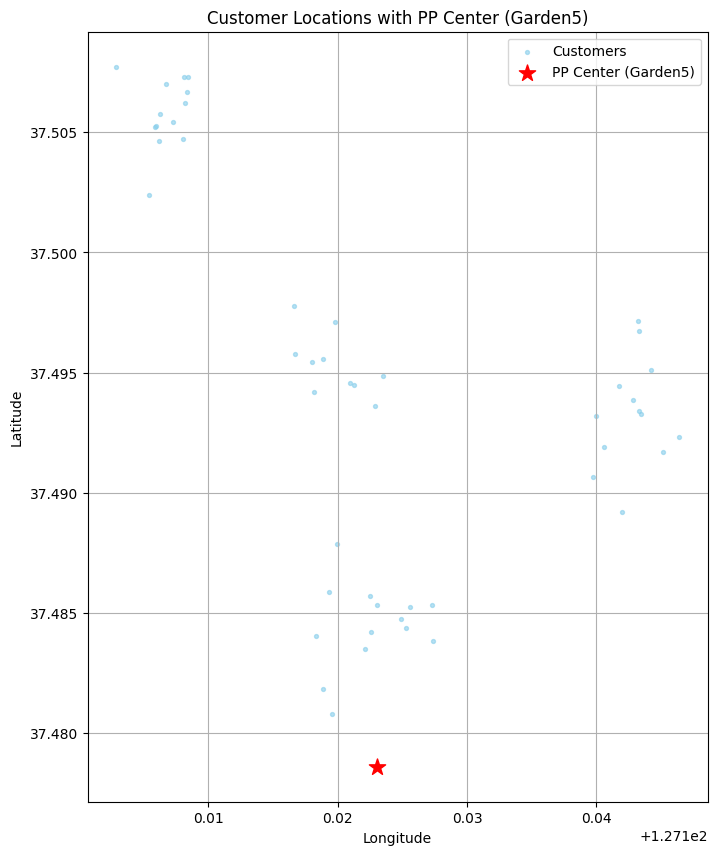

In [11]:
# 시각화 코드 (Matplotlib)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

# 고객 위치
plt.scatter(df["lon"], df["lat"], 
            s=8, alpha=0.6, label="Customers", color="skyblue")

# PP센터 위치
plt.scatter(pp_center["lon"], pp_center["lat"],
            s=150, color="red", marker="*", label="PP Center (Garden5)")

plt.title("Customer Locations with PP Center (Garden5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()


1단계 셀은 데이터/상수/타입 정의만 담당하는 준비 셀

나중에 다른 셀에서 df, pp_center, NodeId, Edge 등을 바로 재사용할 수 있게 해 둔 거고,

typing을 써서 **코드 읽는 사람(팀원, 교수님)**이 각 변수 의미를 바로 알 수 있게 만든 구조

---

# 2단계 : Haversine 거리 계산 + Graph 클래스 + 그래프 생성 함수

- Haversine 공식을 이용해 두 좌표 간 거리를 km 단위로 계산
- Graph 구조를 조금 정리해서 사용
- df + pp_center를 이용해 완전 연결 그래프(모든 노드 쌍 연결) 생성

In [12]:
## ---------------------------------------------------------------------------------------------------------------------
## 거리 계산 함수 + 그래프 클래스 + 그래프 생성 # 일부 보일러플레이트 코드는 AI 도구 도움을 받아 작성함
## ---------------------------------------------------------------------------------------------------------------------
##  거리계산 함수 작성   
### 변수명 lat1, lon1: 첫 번째 지점 위도/경도
### 변수명 lat2, lon2: 두 번째 지점 위도/경도
def haversine_distance(lat1: float, lon1: float,
                    lat2: float, lon2: float) -> float:
    """
    두 지점(위도/경도) 사이의 구면 거리(km)를 계산하는 함수.
    Haversine 공식을 사용한다.
    """
    R = 6371.0  ## 지구 반지름 (km)

    ## 위도/경도를 라디안 단위로 변환
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    d_phi = math.radians(lat2 - lat1)
    d_lambda = math.radians(lon2 - lon1)

    ## Haversine 공식
    a = math.sin(d_phi / 2) ** 2 \
        + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c  ## 최종 거리(km)


In [13]:
## 그래프 클래스 작성 

class Graph:
    """
    고객 + PP센터를 하나의 그래프로 모델링하는 클래스.
    - nodes: 각 노드 id에 대한 (lat, lon)(위도,경도)좌표저장  ##  id -> (lat, lon) 
    - edges: 각 노드 id에 대한 인접 리스트 [(이웃노드, 거리), ...]  각 노드의 id: 인접리스트 저장
    """

    def __init__(self):
        
        self.nodes: Dict[NodeId, Coord] = {} ## 노드 id -> (lat, lon)

        self.edges: Dict[NodeId, List[Edge]] = {} ## 노드 id -> 인접리스트 [(다른 노드 id, 거리), ...]

    def add_node(self, node_id: NodeId, lat: float, lon: float) -> None:
        """
        그래프에 새 노드를 추가한다.
        """
        self.nodes[node_id] = (lat, lon)
        ## 해당 노드의 인접 리스트를 빈 리스트로 초기화
        self.edges[node_id] = []

    def add_edge(self, id1: NodeId, id2: NodeId) -> None:
        """
        두 노드를 양방향 엣지로 연결한다.
        실제 거리는 Haversine으로 계산한다.
        """
        lat1, lon1 = self.nodes[id1]
        lat2, lon2 = self.nodes[id2]
        dist = haversine_distance(lat1, lon1, lat2, lon2)

        ## id1 -> id2
        self.edges[id1].append((id2, dist))
        ## id2 -> id1 (무방향 그래프)
        self.edges[id2].append((id1, dist))


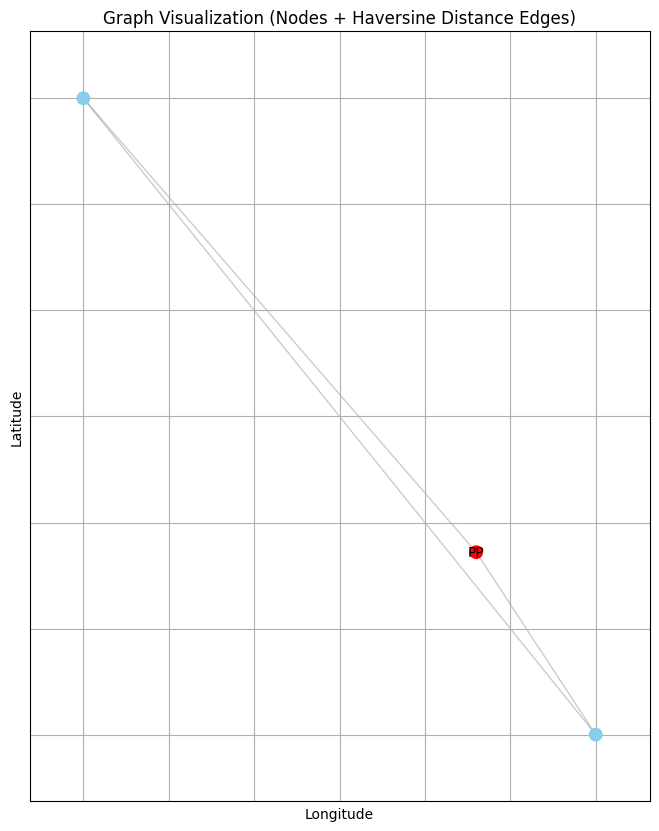

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(graph: Graph):
    """
    Graph 객체를 NetworkX + Matplotlib으로 시각화하는 함수.
    모든 노드를 지도 좌표(lon, lat) 기반으로 배치.
    """
    G = nx.Graph()

    # 1) 노드 추가
    for node_id, (lat, lon) in graph.nodes.items():
        G.add_node(node_id, pos=(lon, lat))  # 지도처럼 (lon, lat) 순서로 넣어야 평면에 자연스럽게 보임

    # 2) 엣지 추가 (거리 weight 포함)
    for node_id, neighbors in graph.edges.items():
        for neighbor_id, dist in neighbors:
            if not G.has_edge(node_id, neighbor_id):
                G.add_edge(node_id, neighbor_id, weight=dist)

    # 3) 위치 설정
    pos = nx.get_node_attributes(G, 'pos')

    plt.figure(figsize=(8, 10))

    # 4) 엣지 그리기
    nx.draw_networkx_edges(
        G, pos,
        edge_color="gray",
        alpha=0.4
    )

    # 5) 노드 표시
    node_colors = ["red" if node == -1 else "skyblue" for node in G.nodes]
    nx.draw_networkx_nodes(
        G, pos,
        node_size=80,
        node_color=node_colors
    )

    # PP센터(-1) 레이블 강조
    labels = {node: ("PP" if node == -1 else "") for node in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

    plt.title("Graph Visualization (Nodes + Haversine Distance Edges)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()
    
# 예시
g = Graph()

# 노드 추가 예시
g.add_node(-1, 37.4786, 127.123)   # PP센터
g.add_node(1, 37.50, 127.10)
g.add_node(2, 37.47, 127.13)

# 엣지 추가
g.add_edge(-1, 1)
g.add_edge(-1, 2)
g.add_edge(1, 2)

visualize_graph(g)



In [15]:
## 그래프 생성 함수 작성하기 

def build_graph_from_df (df: pd.DataFrame, pp_center: Dict) -> Graph:
    """
    CSV(고객 데이터프레임) + PP센터 정보를 받아서
    하나의 완전 연결 그래프를 만드는 헬퍼 함수.
    """
    g = Graph()

    ## 1) PP센터 노드 추가
    g.add_node(pp_center["id"], pp_center["lat"], pp_center["lon"])

    ## 2) 고객 노드 추가
    for _, row in df.iterrows():
        # row['id'], row['lat'], row['lon'] 사용
        g.add_node(int(row["id"]), float(row["lat"]), float(row["lon"]))

    ## 3) 모든 노드 쌍을 완전 연결 (O(N^2))
    all_ids = list(g.nodes.keys())
    for i in range(len(all_ids)):
        for j in range(i + 1, len(all_ids)):
            g.add_edge(all_ids[i], all_ids[j])

    return g


## 실제 그래프 한 번 생성 (기본 전체 고객 대상)
graph = build_graph_from_df(df, pp_center)


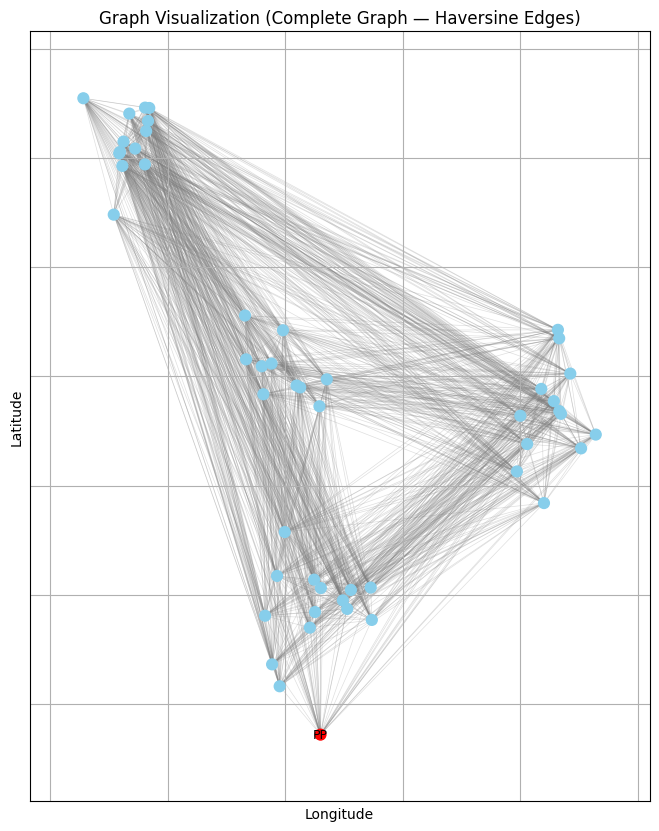

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(graph: Graph):
    """
    Graph 객체를 NetworkX로 시각화.
    노드 위치 = (lon, lat)
    엣지 = haversine 거리
    """
    G = nx.Graph()

    # 노드 추가
    for node_id, (lat, lon) in graph.nodes.items():
        G.add_node(node_id, pos=(lon, lat))

    # 엣지 추가
    for node_id, neighbors in graph.edges.items():
        for neighbor_id, dist in neighbors:
            if not G.has_edge(node_id, neighbor_id):
                G.add_edge(node_id, neighbor_id, weight=dist)

    pos = nx.get_node_attributes(G, "pos")

    plt.figure(figsize=(8, 10))

    # 엣지 시각화
    nx.draw_networkx_edges(
        G, pos,
        edge_color="gray",
        alpha=0.25,
        width=0.5
    )

    # 노드 시각화 (PP센터 = 빨간색)
    node_colors = ["red" if node == -1 else "skyblue" for node in G.nodes]

    nx.draw_networkx_nodes(
        G, pos,
        node_size=60,
        node_color=node_colors
    )

    # 레이블: PP센터만 표시
    labels = {node: ("PP" if node == -1 else "") for node in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=9)

    plt.title("Graph Visualization (Complete Graph — Haversine Edges)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()
    
visualize_graph(graph)


Graph 안에 nodes, edges 딕셔너리를 두고,

build_graph_from_df에서 PP센터 + 고객을 모두 노드로 추가 → 완전연결하는 흐름

이렇게 분리해두면, 나중에 성능 실험에서
df.head(N) 처럼 일부 고객만 써서 그래프를 여러 번 다시 만들 때 재사용

---

# 3단계 : MinHeap (우선순위 큐)


### 1. Heap이란 무엇인가?

: Heap(힙)은 다음과 같은 특징을 가진 특수한 이진 트리 기반 자료구조이다.

- 항상 완전 이진 트리 형태를 유지한다.

- 삽입(push)과 삭제(pop)에서 가장 작은 값 또는 가장 큰 값을 빠르게 꺼낼 수 있다.

- 일반적으로 배열(list)을 이용해 구현한다.

- 핵심 연산의 시간 복잡도는 O(log N)이다.

- Heap은 "우선순위가 가장 높은 요소를 빠르게 꺼내기 위한 트리 구조"라고 이해하면 쉽다.

### 2. MinHeap이란 무엇인가?

MinHeap(최소 힙)은 Heap의 한 종류로, 다음 특징을 가진다.

- 가장 작은 값이 항상 루트(root) 위치에 온다.

- pop() 연산을 하면 가장 작은 값이 반환된다.

:(priority, value) 형태의 데이터를 넣으면, priority가 작은 값이 먼저 나온다.

예시는 다음과 같다.

heap = MinHeap()
heap.push(5.0, "A")
heap.push(2.0, "B")
heap.push(7.0, "C")

priority, value = heap.pop()
--> 결과: (2.0, "B")  — 가장 작은 값이 먼저 나온다.


MinHeap은 내부적으로 다음 두 연산을 이용해 구조를 유지한다.

_heapify_up() : 새 원소 삽입 시 위로 올려서 정렬

_heapify_down() : 루트 원소 제거 후 아래로 내려보내며 정렬

### 3. MinHeap을 왜 쓰는가?

MinHeap은 다음 상황에서 효과적이다.

- 3-1. Prim MST에서의 사용 이유

Prim 알고리즘은 다음 원리로 동작한다.

MST에 포함된 노드에서 바깥으로 나가는 모든 간선 후보를 저장한다.

그 중에서 가중치가 가장 작은 간선 하나만 선택한다.

여기서 여러 개의 간선 중 가장 가벼운 간선을 빠르게 찾기 위해 MinHeap을 사용한다.

heap.push(dist, (from_id, to_id))
dist, (from_id, to_id) = heap.pop()
-> 항상 가장 짧은 간선을 먼저 가져온다.

- 3-2. Dijkstra 최단 경로에서의 사용 이유

Dijkstra 알고리즘도 매 순간:

"현재까지 알려진 거리 중 가장 짧은 거리의 노드"를 꺼내야 한다.

이 기능을 반복적으로 수행하기 때문에, MinHeap이 가장 적절한 자료구조이다.

### 4. Heap은 우선순위 큐(Priority Queue)의 한 구현이다

Heap은 사실상 우선순위 큐(priority queue)를 구현하기 위한 자료구조이다.

다음과 같이 비교할 수 있다.

자료구조	제거 기준	특징
Queue	먼저 들어온 것(FIFO)	순서 중심
Stack	마지막에 들어온 것(LIFO)	되돌아가기 중심
Priority Queue	가장 우선순위 높은 것	기준값(priority) 중심
MinHeap	priority가 가장 작은 요소	Priority Queue의 구현체

우리는 프로젝트에서 “거리(distance)가 작은 것이 우선”이라는 기준을 가지므로 MinHeap을 사용한다.

#### 5. 핵심 요약

- Heap: 중요한 값을 빠르게 꺼내기 위해 만든 이진 트리 기반 자료구조.

- MinHeap: 그 중에서도 가장 작은 값을 빠르게 꺼낼 수 있도록 만든 형태.

#### 프로젝트에서의 역할:

- Prim MST: 가장 짧은 간선을 반복적으로 선택하기 위해 필요.

- Dijkstra: 현재까지 경로가 가장 짧은 노드를 반복적으로 선택하기 위해 필요.

- MinHeap은 우선순위 큐(priority queue)를 구현하는 일반적인 방식이다.

In [17]:
## ----------------------------------------------------------------------------------------------------------------------
## MinHeap (최소 힙) 구현 - # 일부 보일러플레이트 코드는 AI 도구 도움을 받아 작성함
## ----------------------------------------------------------------------------------------------------------------------

class MinHeap:
    
    """
    (priority, value) 튜플을 저장하는 최소 힙 구조.
    - priority: 비교 기준 (거리, 비용 등)
    - value: 노드 id 또는 (from, to) 엣지 정보 등
    """

    def __init__(self):
        ## 내부 리스트: 완전이진트리 형태의 힙 저장소
        self.heap: List[Tuple[float, object]] = [] # [(우선순위1, 값1), (우선순위2, 값2), ...]

    def __len__(self) -> int:
        ## len(heap_obj)로 현재 원소 개수를 알 수 있게 함
        return len(self.heap)

    def is_empty(self) -> bool:
        ## 힙이 비었는지 여부 반환
        return len(self.heap) == 0

    def _swap(self, i: int, j: int) -> None:
        ## 내부 유틸: i번째, j번째 원소를 교환
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]

    def _heapify_up(self, idx: int) -> None:
        """
        새 원소가 마지막에 들어왔을 때,
        힙 조건을 만족할 때까지 위쪽으로 끌어올리는 작업.
        """
        while idx > 0:
            parent = (idx - 1) // 2  ## 부모 인덱스
            if self.heap[idx][0] < self.heap[parent][0]:
                ## 자식 priority가 더 작으면 교환
                self._swap(idx, parent)
                idx = parent
            else:
                ## 이미 부모가 더 작거나 같으면 종료
                break

    def _heapify_down(self, idx: int) -> None:
        """
        루트에서 원소를 꺼낸 뒤,
        아래로 내려가면서 힙 조건을 만족시키도록 재배치하는 작업.
        """
        size = len(self.heap)
        while True:
            left = 2 * idx + 1   ## 왼쪽 자식 인덱스
            right = 2 * idx + 2  ## 오른쪽 자식 인덱스
            smallest = idx       ## 일단 현재 인덱스를 가장 작은 것으로 가정

            ## 왼쪽 자식 존재 + 더 작으면 교체 후보
            if left < size and self.heap[left][0] < self.heap[smallest][0]:
                smallest = left
            ## 오른쪽 자식 존재 + 지금까지 가장 작은 것보다 작으면 교체 후보
            if right < size and self.heap[right][0] < self.heap[smallest][0]:
                smallest = right

            if smallest != idx:
                ## 두 자식 중 더 작은 쪽과 교환 후 계속 내려감
                self._swap(idx, smallest)
                idx = smallest
            else:
                ## 더 이상 내려갈 필요 없으면 종료
                break

    def push(self, priority: float, value: object) -> None:
        """
        (priority, value) 원소를 힙에 삽입.
        """
        ## 뒤에 원소를 추가하고
        self.heap.append((priority, value))
        ## 위로 끌어올리며 재정렬
        self._heapify_up(len(self.heap) - 1)

    def pop(self) -> Tuple[float, object]:
        """
        힙에서 priority가 가장 작은 원소를 꺼내 반환.
        """
        if self.is_empty():
            raise IndexError("pop from empty heap")

        ## 루트 원소(최소 priority)를 result에 저장
        root_priority, root_value = self.heap[0]

        ## 마지막 원소를 루트 위치로 가져다 놓고
        last = self.heap.pop()
        if self.heap:
            self.heap[0] = last
            ## 루트에서 아래로 내려가며 힙 재정렬
            self._heapify_down(0)

        return root_priority, root_value


# 힙 생성
h = MinHeap()

# push
h.push(5, "A")
h.push(3, "B")
h.push(8, "C")
h.push(1, "D")
h.push(7, "E")

# pop 실행
h.pop()

# MinHeap (최소 힙) Push / Pop 동작 시각화

---

## ✅ 1. push: 삽입 → 위로 올라가기 (heapify_up)

push 연산은 다음 순서로 진행됩니다:

1. 배열 끝에 새 노드 추가
2. 부모와 비교해서 **더 작으면 위로 올라감** (heapify_up)

즉, **삽입 → 위로 올라가기(상향 힙 정렬)** 과정입니다.

---

### 🔍 Push 5개 예시 (priority, value)

Step 1: push(5, A)

  (5,A)

Step 2: push(3, B)
3이 5보다 작아서 위로 이동

 (3,B)
   |
 (5,A)


Step 3: push(8, C)
8은 부모 3보다 크므로 그대로

    (3,B)
   /     \
(5,A)   (8,C)


Step 4: push(1, D)
1이 부모 5보다 작음 → swap
루트 3보다 작음 → 또 swap

      (1,D)
     /     \
  (3,B)   (8,C)
  /
(5,A)


Step 5: push(7, E)
7은 부모 3보다 크므로 그대로

         (1,D)
       /       \
   (3,B)       (8,C)
   /   \
(5,A) (7,E)


---

### 🎯 push 핵심 요약
- 항상 배열 **맨 뒤에 삽입**  
- 부모보다 priority가 작으면 **위로 올라감** (heapify_up)  
- → 최소 힙 조건: **최소값(min)** 항상 루트에 위치

---

## ✅ 2. pop: 삭제 → 아래로 내려가기 (heapify_down)

pop 연산은 push의 반대 과정입니다:

1. 루트(최소값) 제거  
2. 배열 마지막 노드를 루트로 이동  
3. 더 작은 자식 방향으로 아래로 내려가며 재정렬 (heapify_down)

즉, **삭제 → 아래로 내려가기(하향 힙 정렬)** 과정입니다.

---

### 🔍 Pop 후 내부 변화 예시

원래 힙:


         (1,D)
       /       \
   (3,B)       (8,C)
   /   \
(5,A) (7,E)

#### Step 1: pop → 루트 (1,D) 제거
배열 마지막 노드 (7,E)를 루트로 이동

        (7,E)
       /     \
   (3,B)     (8,C)
   /
(5,A)

#### Step 2: heapify_down
7은 자식 중 더 작은 3보다 크므로 swap

        (7,E)
       /     \
   (3,B)      (8,C)
   /    
(5,A)


#### Step 3: 7은 자식 5보다 크므로 또 swap

        (3,B)
       /     \
   (5,A)      (8,C)
   /    
(7,E)


---

### 🎯 pop 핵심 요약
- **루트(최소값)를 꺼내는 연산**  
- 마지막 노드를 루트로 올리고 **아래로 내려감** (heapify_down)  
- → 최소 힙 조건을 유지하며 최소값 제거


insert/pop 모두 O(log N) 레벨로 동작해.

Prim MST 구현, 나중에 Dijkstra 추가할 때도 그대로 재사용 가능

---

# 4단계 : Greedy 경로(Nearest Neighbor) + Prim MST

- Greedy: 항상 “가장 가까운 다음 고객”으로만 이동하는 간단 휴리스틱

- Prim MST: 전체 그래프의 최소 신장 트리를 생성

In [18]:
## -----------------------------------------------------------------------------------------------------------------------
## Greedy 경로 알고리즘 + Prim MST + MST → 경로 변환 - # 일부 보일러플레이트 코드는 AI 도구 도움을 받아 작성함
## -----------------------------------------------------------------------------------------------------------------------

## Greedy 경로 알고리즘 작성하기
def greedy_route(graph: Graph, start_id: NodeId) -> List[NodeId]:
    """
    Greedy(Nearest Neighbor) 알고리즘으로 경로를 생성한다.
    - 현재 위치에서 '방문하지 않은 노드 중 가장 가까운 노드'를 반복 선택.
    - 전체 최적(TSP)은 아니지만, 직관적인 휴리스틱.
    """
    visited = set([start_id])      ## 이미 방문한 노드 집합
    route: List[NodeId] = [start_id]  ## 경로 리스트 (방문 순서 기록)
    current = start_id             ## 현재 위치

    ## 모든 노드를 방문할 때까지 반복
    while len(visited) < len(graph.nodes):
        min_dist = float("inf")    ## 현재 단계에서의 최솟값 초기화  
        next_id = None             ## 다음에 갈 후보 노드

        ## 현재 노드의 모든 이웃을 확인하면서
        for neighbor_id, dist in graph.edges[current]:
            ## 아직 방문하지 않았고, 거리가 더 짧으면 선택
            if neighbor_id not in visited and dist < min_dist:
                min_dist = dist
                next_id = neighbor_id

        ## 더 이상 방문할 노드가 없으면 루프 종료
        if next_id is None:
            break

        ## 다음 노드 방문 처리
        route.append(next_id)
        visited.add(next_id)
        current = next_id

    return route



# Greedy 경로 알고리즘 (Nearest Neighbor) 시각화

---

## ✅ 알고리즘 개요
- 시작 노드에서 출발
- **현재 위치에서 방문하지 않은 노드 중 가장 가까운 노드** 선택
- 모든 노드를 방문할 때까지 반복
- **휴리스틱 방식으로 생성된 경로**로, 전체 최적(TSP) 경로를 항상 보장하지는 않음

## 💡 Tip:

- 빨간 선은 Greedy 알고리즘으로 선택된 순서대로 연결된 경로
- 초록 점은 시작점(PP센터)
- 파란 점은 나머지 노드
- 각 노드 번호를 표시하여 경로 순서 직관적 확인 가능

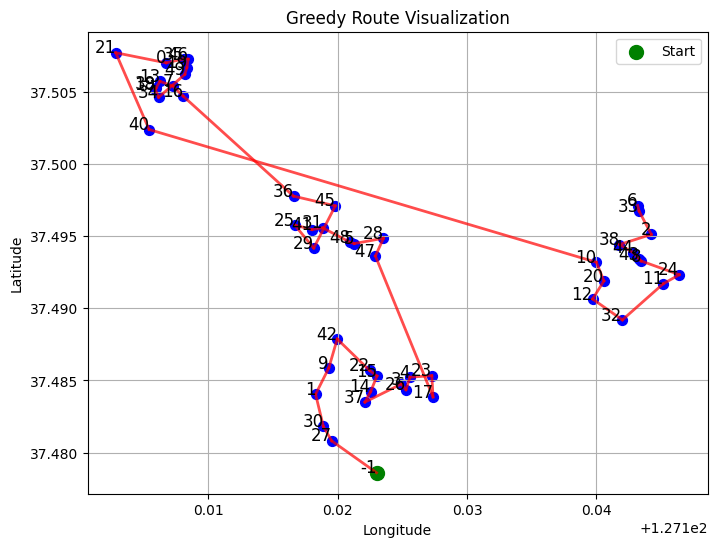

In [19]:
import matplotlib.pyplot as plt

def visualize_greedy_route(graph: Graph, route: List[NodeId]):
    plt.figure(figsize=(8, 6))
    
    # 1) 모든 노드 표시
    for node_id, (lat, lon) in graph.nodes.items():
        plt.scatter(lon, lat, c='blue', s=50)
        plt.text(lon, lat, str(node_id), fontsize=12, color='black', ha='right')

    # 2) 경로 표시
    for i in range(len(route) - 1):
        id1, id2 = route[i], route[i+1]
        lat1, lon1 = graph.nodes[id1]
        lat2, lon2 = graph.nodes[id2]
        plt.plot([lon1, lon2], [lat1, lat2], 'r-', linewidth=2, alpha=0.7)

    # 3) 시작 노드 강조
    start_id = route[0]
    lat0, lon0 = graph.nodes[start_id]
    plt.scatter(lon0, lat0, c='green', s=100, label='Start')

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Greedy Route Visualization')
    plt.grid(True)
    plt.legend()
    plt.show()
    
route = greedy_route(graph, start_id=-1)  # PP센터에서 시작
visualize_greedy_route(graph, route)


In [20]:
## Prim MST 알고리즘 작성하기

def prim_mst(graph: Graph, start_id: NodeId) -> List[Tuple[NodeId, NodeId]]:
    """
    Prim 알고리즘으로 MST(최소 신장 트리)를 구성.
    반환값은 (from_id, to_id) 엣지들의 리스트.
    """
    visited = set([start_id])    ## MST에 포함된 노드 집합
    heap = MinHeap()             ## (거리, (from, to))를 담는 최소 힙

    ## 시작 노드에서 나가는 모든 엣지를 힙에 넣는다.
    for neighbor_id, dist in graph.edges[start_id]:  ## dist:  
        heap.push(dist, (start_id, neighbor_id))  

    mst_edges: List[Tuple[NodeId, NodeId]] = []  ## MST를 구성하는 엣지들

    ## 힙이 빌 때까지, 그리고 모든 노드를 MST에 포함할 때까지 반복
    while not heap.is_empty() and len(visited) < len(graph.nodes):
        dist, (from_id, to_id) = heap.pop()

        ## 이미 방문한(to_id가 MST 집합에 있는) 노드라면 무시
        if to_id in visited:
            continue

        ## 새 노드를 MST에 편입
        mst_edges.append((from_id, to_id))
        visited.add(to_id)

        ## 새로 편입된 노드에서 나가는 엣지를 전부 힙에 추가
        for neighbor_id, ndist in graph.edges[to_id]:
            if neighbor_id not in visited:
                heap.push(ndist, (to_id, neighbor_id))

    return mst_edges



# Prim MST 알고리즘 시각화

---

## ✅ 알고리즘 개요
- **Prim 알고리즘**을 사용하여 MST(최소 신장 트리) 구성
- 시작 노드에서 출발
- 최소 힙(MinHeap)을 사용하여 **현재 MST에 연결된 최소 비용 엣지 선택**
- 이미 MST에 포함된 노드면 무시
- 모든 노드를 포함할 때까지 반복

## 💡 Tip:
- 초록 선: Prim MST로 선택된 엣지
- 파란 점: 노드 위치
- MST는 최소 총 거리로 모든 노드를 연결하며, 사이클이 없음

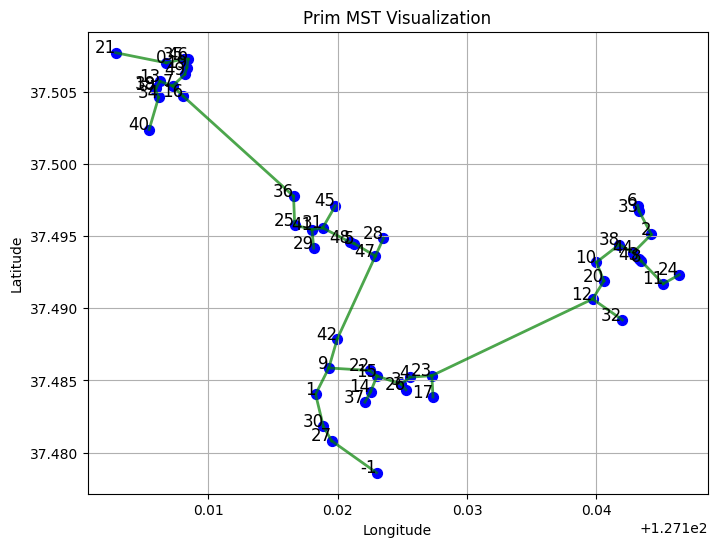

In [21]:
import matplotlib.pyplot as plt

def visualize_mst(graph: Graph, mst_edges: List[Tuple[NodeId, NodeId]]):
    plt.figure(figsize=(8, 6))

    # 1) 모든 노드 표시
    for node_id, (lat, lon) in graph.nodes.items():
        plt.scatter(lon, lat, c='blue', s=50)
        plt.text(lon, lat, str(node_id), fontsize=12, color='black', ha='right')

    # 2) MST 엣지 표시
    for from_id, to_id in mst_edges:
        lat1, lon1 = graph.nodes[from_id]
        lat2, lon2 = graph.nodes[to_id]
        plt.plot([lon1, lon2], [lat1, lat2], 'g-', linewidth=2, alpha=0.7)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Prim MST Visualization')
    plt.grid(True)
    plt.show()
mst_edges = prim_mst(graph, start_id=-1)  # PP센터 시작
visualize_mst(graph, mst_edges)


In [22]:
## MST → 경로 변환 함수 작성하기

def mst_to_route(mst_edges: List[Tuple[NodeId, NodeId]],
                start_id: NodeId) -> List[NodeId]:
    """
    MST 엣지 리스트를 이용해, 스택(DFS)을 활용한 방문 순서(route)를 만든다.
    - 실제로는 '트리 순회 경로'에 가깝고, TSP 최적해는 아님.
    - 하지만 MST 기반 라우팅 휴리스틱으로 사용할 수 있음.
    """
    from collections import defaultdict

    ## 1) MST 엣지들을 인접 리스트 형태로 변환
    adj = defaultdict(list)
    for f, t in mst_edges:
        adj[f].append(t)
        adj[t].append(f)

    ## 2) DFS를 위한 스택/방문집합/경로 리스트 초기화   #### ++ 스택 활용 - 스택을 활용한 경로 생성(DFS기반)
    route: List[NodeId] = []
    stack: List[NodeId] = [start_id]   ## 스택(LIFO) - 마지막에 넣은 노드부터 꺼내 탐색
    visited = set()

    ## 3) 스택을 이용한 DFS
    while stack:
        node = stack.pop()             ## 스택 최상단 원소 꺼내기 제일 위에꺼
        if node not in visited:
            visited.add(node)          ## 방문 표시
            route.append(node)         ## 방문 순서 기록

            ## 이웃 노드들 중 아직 방문하지 않은 노드를 스택에 추가
            ## (LIFO 특성상, 나중에 추가된 노드가 먼저 탐색됨)
            for neighbor in adj[node]:
                if neighbor not in visited:
                    stack.append(neighbor)

    return route


# MST → 경로 변환 (DFS 기반) 시각화

---

## ✅ 알고리즘 개요
- MST(Prim으로 구성된 최소 신장 트리) 엣지 리스트를 이용
- DFS(Stack)를 활용하여 방문 순서(route) 생성
- 실제 TSP 최적해는 아니지만 **MST 기반 라우팅 휴리스틱**으로 사용 가능

## 💡 Tip:
- 보라색 선: MST 기반 DFS 경로
- 초록 점: 시작점(PP센터)
- 파란 점: 나머지 노드
- MST → DFS 순회 기반이므로 TSP 최적 경로는 아님
- 하지만 실제 물류/배송 시 휴리스틱 경로로 충분히 활용 가능


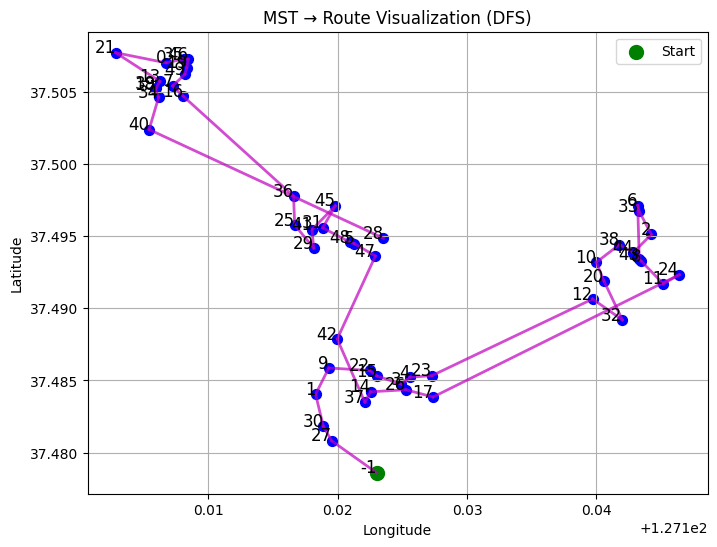

In [23]:
import matplotlib.pyplot as plt

def visualize_mst_route(graph: Graph, route: List[NodeId]):
    plt.figure(figsize=(8, 6))

    # 1) 모든 노드 표시
    for node_id, (lat, lon) in graph.nodes.items():
        plt.scatter(lon, lat, c='blue', s=50)
        plt.text(lon, lat, str(node_id), fontsize=12, color='black', ha='right')

    # 2) DFS 기반 경로 표시
    for i in range(len(route) - 1):
        id1, id2 = route[i], route[i+1]
        lat1, lon1 = graph.nodes[id1]
        lat2, lon2 = graph.nodes[id2]
        plt.plot([lon1, lon2], [lat1, lat2], 'm-', linewidth=2, alpha=0.7)

    # 3) 시작 노드 강조
    start_id = route[0]
    lat0, lon0 = graph.nodes[start_id]
    plt.scatter(lon0, lat0, c='green', s=100, label='Start')

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('MST → Route Visualization (DFS)')
    plt.grid(True)
    plt.legend()
    plt.show()
    
mst_edges = prim_mst(graph, start_id=-1)      # MST 생성
route = mst_to_route(mst_edges, start_id=-1) # DFS 기반 경로 생성
visualize_mst_route(graph, route)            # 시각화



---

# 5단계 : 경로 총 이동 거리 계산 함수

- 어떤 경로 리스트 [노드1, 노드2, ...]가 들어왔을 때, 그래프의 edges를 참고해서 총 이동 거리(km) 계산

In [24]:
## ----------------------------------------------------------------------------------------------------------------------
## 경로의 총 이동 거리 계산 헬퍼 - # 일부 보일러플레이트 코드는 AI 도구 도움을 받아 작성함
## ----------------------------------------------------------------------------------------------------------------------

def calculate_route_total_distance(graph: Graph, route: List[NodeId]) -> float:
    """
    경로(route)에 대해 총 이동 거리를 계산한다.
    route = [n0, n1, n2, ...] 이면,
    n0->n1, n1->n2, ... 의 거리를 전부 합산.
    """
    total_distance = 0.0

    ## 인접 리스트에서 from_node -> to_node 엣지를 찾아 거리 누적
    for i in range(len(route) - 1):
        from_node = route[i]
        to_node = route[i + 1]

        found = False  ## 디버깅용 플래그 (엣지 존재 여부 확인) : 엣지 찾았는지 여부
        for neighbor_id, dist in graph.edges[from_node]:
            if neighbor_id == to_node:
                total_distance += dist
                found = True
                break

        ## 만약 엣지를 못 찾으면(그래프 구성상 문제) 디버깅 메시지 도움될 수 있음
        if not found:
            # 필요하면 print문 열어서 확인 가능
            # print(f"[WARN] Edge from {from_node} to {to_node} not found.")
            pass

    return total_distance


Greedy, MST 둘 다 공통으로 사용할 수 있음

# 경로 총 이동 거리 계산

---

## ✅ 알고리즘 개요
- 주어진 경로(route)에 대해 **총 이동 거리** 계산
- 경로 예: `[n0, n1, n2, ...]` → 거리 합산: `n0->n1 + n1->n2 + ...`
- MST 기반 경로, Greedy 경로 등 모든 NodeId 리스트에 적용 가능

💡 Tip:
- MST→DFS 경로는 휴리스틱 기반으로 Greedy와 비교 가능
- calculate_route_total_distance를 통해 두 경로의 총 이동 거리 차이를 정량적으로 확인 가능

In [25]:
# Greedy 경로
greedy_route_list = greedy_route(graph, start_id=-1)
greedy_distance = calculate_route_total_distance(graph, greedy_route_list)
print(f"Greedy route total distance: {greedy_distance:.2f} km")

# MST 기반 DFS 경로
mst_edges = prim_mst(graph, start_id=-1)
mst_route_list = mst_to_route(mst_edges, start_id=-1)
mst_distance = calculate_route_total_distance(graph, mst_route_list)
print(f"MST→DFS route total distance: {mst_distance:.2f} km")

Greedy route total distance: 13.60 km
MST→DFS route total distance: 14.88 km


---

# 6단계 : 셀 6. 성능 실험 루프 (N=10/50/100)

- N(고객 수)을 바꿔가며 그래프를 다시 만들고, Greedy / MST 각각에 대해

실행 시간(ms), 총 이동 거리(km) 를 측정해서 출력.

In [26]:
## ---------------------------------------------------------------------------------------------------------------------
## 성능 실험 (N=10, 50, 100) # 일부 보일러플레이트 코드는 AI 도구 도움을 받아 작성함
## -----------------------------------------------------------------------------------------------------------------------

import time
import random

## 재현성을 위해 시드 고정  (확인 필요)
random.seed(42)

N_list = [10, 50, 100]

for N in N_list:
    ## 1) N에 맞게 고객 데이터 서브셋 만들기
    ##    - df에서 고객 N명을 샘플링 (seed 고정)
    if N <= len(df):
        df_sub = df.sample(n=N, random_state=42).reset_index(drop=True)
    else:
        ## N이 전체 고객 수보다 크면, 전체 사용
        df_sub = df.copy().reset_index(drop=True)

    ## 2) 서브셋 데이터 기반으로 새 그래프 생성
    g_N = build_graph_from_df(df_sub, pp_center)

    ## 3) Greedy 경로 생성 및 측정
    start_time = time.time()
    greedy_route_result = greedy_route(g_N, pp_center["id"])
    greedy_time = (time.time() - start_time) * 1000.0  # ms 단위

    greedy_distance = calculate_route_total_distance(g_N, greedy_route_result)

    ## 4) MST 기반 경로 생성 및 측정
    start_time = time.time()
    mst_edges = prim_mst(g_N, pp_center["id"])
    mst_route_result = mst_to_route(mst_edges, pp_center["id"])
    mst_time = (time.time() - start_time) * 1000.0  # ms 단위

    mst_distance = calculate_route_total_distance(g_N, mst_route_result)

    ## 5) 결과 출력
    print(f"[N={N}] Greedy  : 거리={greedy_distance:.2f} km, 시간={greedy_time:.1f} ms")
    print(f"[N={N}] MST-DFS: 거리={mst_distance:.2f} km, 시간={mst_time:.1f} ms")
    print("-" * 60)


[N=10] Greedy  : 거리=8.50 km, 시간=0.0 ms
[N=10] MST-DFS: 거리=9.11 km, 시간=0.0 ms
------------------------------------------------------------
[N=50] Greedy  : 거리=13.60 km, 시간=0.0 ms
[N=50] MST-DFS: 거리=14.88 km, 시간=6.0 ms
------------------------------------------------------------
[N=100] Greedy  : 거리=13.60 km, 시간=1.0 ms
[N=100] MST-DFS: 거리=14.88 km, 시간=2.0 ms
------------------------------------------------------------


이거 시간 너무 짧게 막 0 초 나오고 이런거는 고객 수를 적게 잡은거여서 n바꾸면 되는거고, 소수점 까지 보고싶으면 4f이런식으로 바꾸면 됨

고객 수 N 변경하면서, 각 알고리즘별 총 이동거리/실행 시간 측정

N마다 그래프를 새로 만들기 때문에, “입력 규모 확장 실험”이 명확하게 드러남

Greedy vs MST의 거리·시간 차이를 표/그래프로 그려서 PPT에 넣으면,
평가 기준의 “실험/평가(15점)” 항목을 제대로 채울 수 있음

# 성능 실험 (Greedy vs MST→DFS)  

---

## ✅ 개요
- 고객 수 N = 10, 50, 100에 대해 성능 비교
- 비교 대상:
  1. **Greedy 경로** (Nearest Neighbor)
  2. **MST→DFS 경로** (Prim MST 기반)
- 측정 항목:
  - 총 이동 거리 (km)
  - 연산 시간 (ms)

## 🔹 Tip
- Greedy:
    - 간단하고 직관적
    - 계산량 적지만, **휴리스틱 방식으로 생성된 경로**라 전체 최적(TSP) 경로를 항상 보장하지는 않음
- MST→DFS:
    - MST 기반 휴리스틱
    - 조금 더 계산 필요하지만, Greedy보다 전체 거리가 짧을 가능성 있음
- N 증가 시 연산 시간과 경로 길이 변화를 관찰 가능


# 7. 검증: Baseline vs Greedy vs MST
- 목적: 동일한 고객 샘플(df_sub)과 동일 거리공식(haversine), 동일 Graph에서
  Baseline(Queue), Greedy(NN), MST→DFS 경로의 **총 이동거리**와 **계산시간(ms)** 을 비교한다.
- 출력: 각 방법의 경로, 총거리, 소요시간, 개선율(%) 표기


In [27]:
# --- 7. 검증 실행 코드 (복사/실행용) ---
import time
import pandas as pd
import random

random.seed(42)

# N 리스트 (원하면 변경)
N_list = [10, 50, 100]

results = []  # 결과 저장(추후 시각화용)

for N in N_list:
    print(f"\n==== Validation N={N} ====")

    # --- N 자동 보정(오류 방지) ---
    if N > len(df):
        print(f"⚠ 경고: 요청한 N({N}) > df 크기({len(df)}). 자동으로 N={len(df)}로 조정합니다.")
        N_safe = len(df)
    else:
        N_safe = N

    # 동일 샘플링
    df_sub = df.sample(n=N_safe, random_state=42).reset_index(drop=True)

    # Graph 생성 (실험군과 동일 함수 사용)
    g_N = build_graph_from_df(df_sub, pp_center)

    # 1) Baseline
    start = time.time()
    baseline_route = baseline_queue_route(pp_center, df_sub)
    baseline_time = (time.time() - start) * 1000.0
    baseline_dist = calculate_route_total_distance(g_N, baseline_route)

    # 2) Greedy
    start = time.time()
    greedy_route_result = greedy_route(g_N, pp_center["id"])
    greedy_time = (time.time() - start) * 1000.0
    greedy_dist = calculate_route_total_distance(g_N, greedy_route_result)

    # 3) MST -> DFS
    start = time.time()
    mst_edges = prim_mst(g_N, pp_center["id"])
    mst_route_result = mst_to_route(mst_edges, pp_center["id"])
    mst_time = (time.time() - start) * 1000.0
    mst_dist = calculate_route_total_distance(g_N, mst_route_result)

    # 개선율 계산
    greedy_improve_pct = (baseline_dist - greedy_dist) / baseline_dist * 100 if baseline_dist > 0 else 0.0
    mst_improve_pct = (baseline_dist - mst_dist) / baseline_dist * 100 if baseline_dist > 0 else 0.0

    # 출력
    print(f"[Baseline] 거리={baseline_dist:.3f} km | 시간={baseline_time:.1f} ms")
    print(f"[Greedy  ] 거리={greedy_dist:.3f} km | 시간={greedy_time:.1f} ms | 개선율={greedy_improve_pct:.2f}%")
    print(f"[MST-DFS ] 거리={mst_dist:.3f} km | 시간={mst_time:.1f} ms | 개선율={mst_improve_pct:.2f}%")

    # 결과 저장
    results.append({
        "N": N_safe,
        "baseline_dist": baseline_dist, "baseline_time": baseline_time,
        "greedy_dist": greedy_dist, "greedy_time": greedy_time, "greedy_improve_pct": greedy_improve_pct,
        "mst_dist": mst_dist, "mst_time": mst_time, "mst_improve_pct": mst_improve_pct,
        "baseline_route": baseline_route,
        "greedy_route": greedy_route_result,
        "mst_route": mst_route_result
    })



==== Validation N=10 ====
[Baseline] 거리=19.485 km | 시간=0.0 ms
[Greedy  ] 거리=8.503 km | 시간=0.0 ms | 개선율=56.36%
[MST-DFS ] 거리=9.105 km | 시간=0.0 ms | 개선율=53.27%

==== Validation N=50 ====
[Baseline] 거리=104.374 km | 시간=1.0 ms
[Greedy  ] 거리=13.604 km | 시간=0.0 ms | 개선율=86.97%
[MST-DFS ] 거리=14.876 km | 시간=4.0 ms | 개선율=85.75%

==== Validation N=100 ====
⚠ 경고: 요청한 N(100) > df 크기(50). 자동으로 N=50로 조정합니다.
[Baseline] 거리=104.374 km | 시간=3.0 ms
[Greedy  ] 거리=13.604 km | 시간=0.0 ms | 개선율=86.97%
[MST-DFS ] 거리=14.876 km | 시간=3.0 ms | 개선율=85.75%


# 8. 성능 비교 시각화
- 막대그래프: 각 N에 대해 Baseline / Greedy / MST 경로 총거리 비교
- 개선율 그래프: 각 방법(Greedy/MST)의 Baseline 대비 개선율(%)
- 시간 비교: 각 방법의 계산시간(ms) 막대그래프


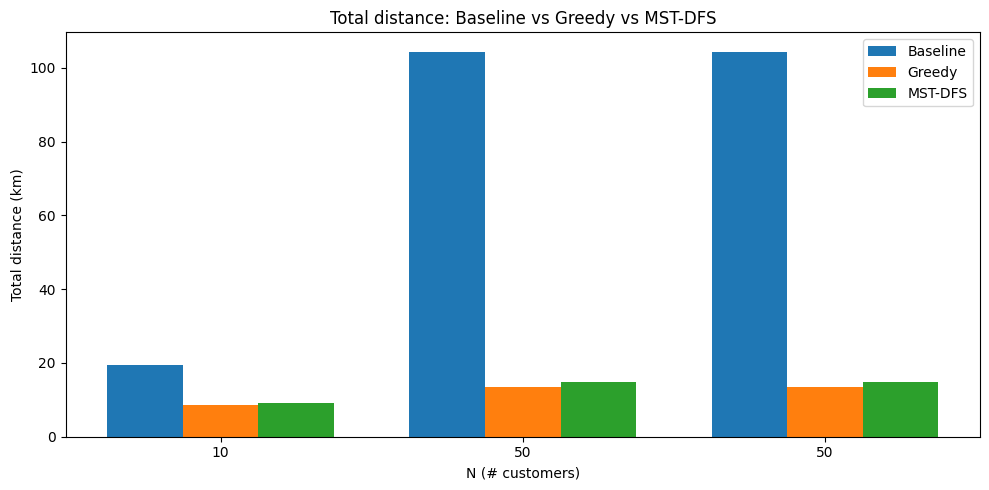

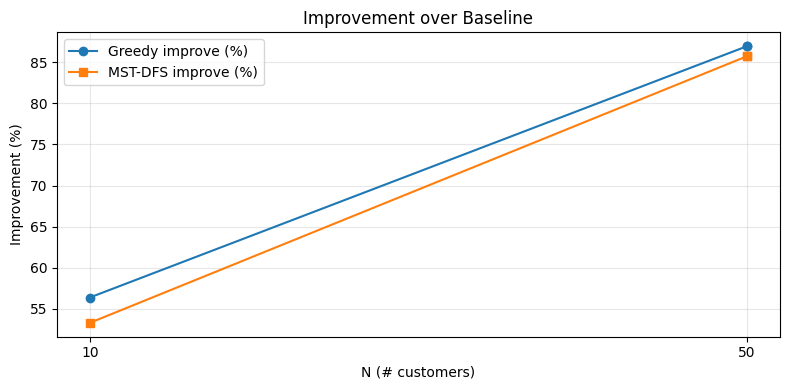

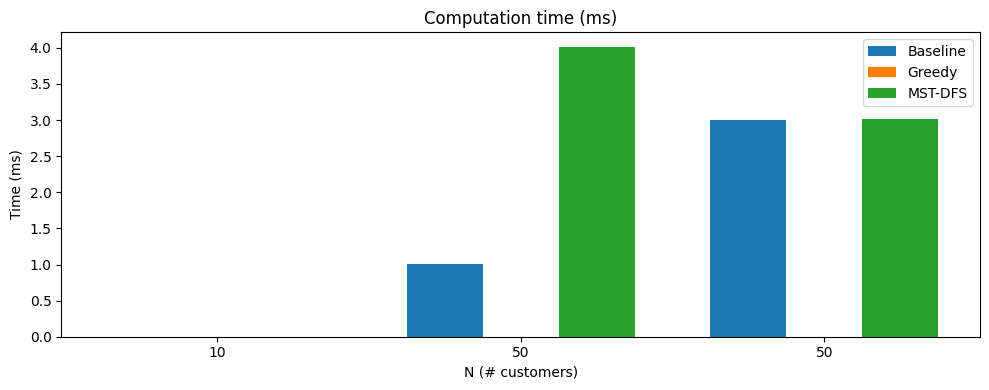

In [28]:
# --- 8. 시각화 코드 (matplotlib) ---
import matplotlib.pyplot as plt
import numpy as np

# DataFrame으로 정리
res_df = pd.DataFrame(results).set_index("N")

# 8-1: 거리 비교 (막대)
labels = res_df.index.astype(str)
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width, res_df["baseline_dist"], width, label="Baseline")
ax.bar(x, res_df["greedy_dist"], width, label="Greedy")
ax.bar(x + width, res_df["mst_dist"], width, label="MST-DFS")
ax.set_xlabel("N (# customers)")
ax.set_ylabel("Total distance (km)")
ax.set_title("Total distance: Baseline vs Greedy vs MST-DFS")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

# 8-2: 개선율 비교 (Greedy / MST)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(labels, res_df["greedy_improve_pct"], marker="o", label="Greedy improve (%)")
ax.plot(labels, res_df["mst_improve_pct"], marker="s", label="MST-DFS improve (%)")
ax.set_xlabel("N (# customers)")
ax.set_ylabel("Improvement (%)")
ax.set_title("Improvement over Baseline")
ax.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8-3: 시간 비교 (ms)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(x - width, res_df["baseline_time"], width, label="Baseline")
ax.bar(x, res_df["greedy_time"], width, label="Greedy")
ax.bar(x + width, res_df["mst_time"], width, label="MST-DFS")
ax.set_xlabel("N (# customers)"); ax.set_ylabel("Time (ms)")
ax.set_title("Computation time (ms)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()


## 복잡도 계산 및 시각화

#### 각 알고리즘 별 공간복잡도와 시간복잡도
- baseline (Queue)
  - 시간복잡도: O(N) - 단순 순회
  - 공간복잡도: O(N) - 방문 여부 저장용 집합
- Greedy (Nearest Neighbor)
  - 시간복잡도: O(N^2) - 매 단계마다 모든 미방문 노드를 탐색
  - 공간복잡도: O(N) - 방문 여부 저장용 집합
- MST-DFS (Prim MST + DFS 순회)
    - 시간복잡도: O(E log E) + O(V) ≈ O(N² log N) - MST 생성이 지배적
    - 공간복잡도: O(E) + O(V) ≈ O(N²) - 힙 및 인접 리스트 저장

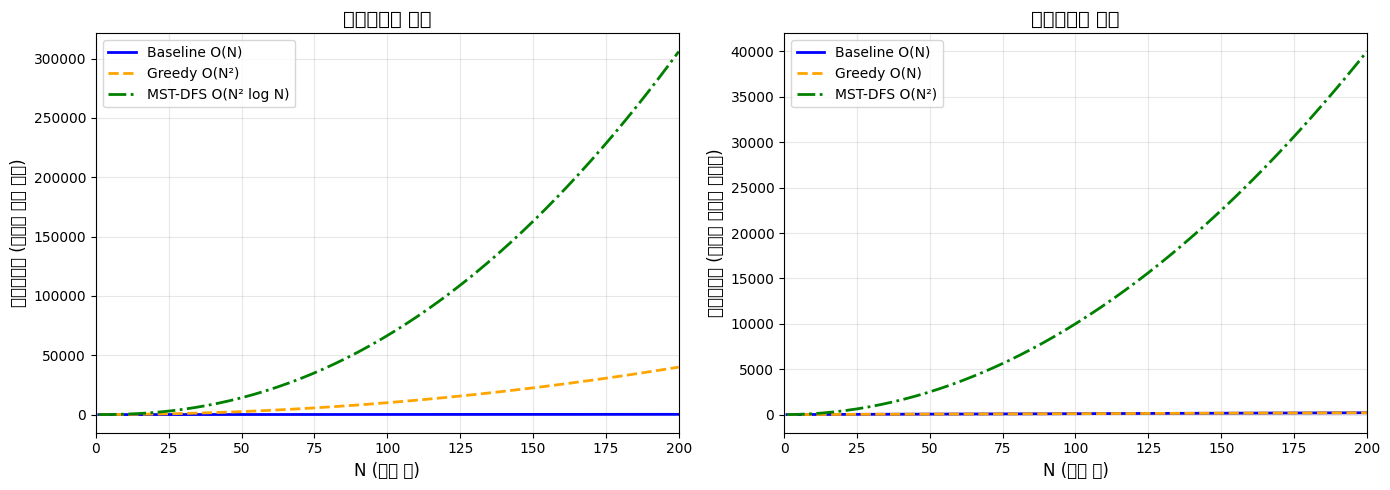


=== N 값별 시간복잡도 비교 (상대적 크기) ===
N        Baseline     Greedy       MST-DFS        
--------------------------------------------------
10       10           100          305754.2       
50       50           2500         332.2          
100      100          10000        14109.6        
200      200          40000        66438.6        


In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

# N 범위 설정
N = np.arange(1, 201, 1)

# 시간복잡도 계산 (3가지 알고리즘만)
time_baseline = N                       # Baseline: O(N)
time_greedy = N ** 2                    # Greedy: O(N²)
time_mst_dfs = N ** 2 * np.log2(N + 1)  # MST-DFS: O(N² log N)

# 공간복잡도 계산 (3가지 알고리즘만)
space_baseline = N                       # Baseline: O(N)
space_greedy = N                         # Greedy: O(N)
space_mst_dfs = N ** 2                   # MST-DFS: O(N²)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 시간복잡도 그래프
ax1 = axes[0]
ax1.plot(N, time_baseline, label='Baseline O(N)', linestyle='-', linewidth=2, color='blue')
ax1.plot(N, time_greedy, label='Greedy O(N²)', linestyle='--', linewidth=2, color='orange')
ax1.plot(N, time_mst_dfs, label='MST-DFS O(N² log N)', linestyle='-.', linewidth=2, color='green')
ax1.set_xlabel('N (고객 수)', fontsize=12)
ax1.set_ylabel('시간복잡도 (상대적 연산 횟수)', fontsize=12)
ax1.set_title('시간복잡도 비교', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 200])

# 2) 공간복잡도 그래프
ax2 = axes[1]
ax2.plot(N, space_baseline, label='Baseline O(N)', linestyle='-', linewidth=2, color='blue')
ax2.plot(N, space_greedy, label='Greedy O(N)', linestyle='--', linewidth=2, color='orange')
ax2.plot(N, space_mst_dfs, label='MST-DFS O(N²)', linestyle='-.', linewidth=2, color='green')
ax2.set_xlabel('N (고객 수)', fontsize=12)
ax2.set_ylabel('공간복잡도 (상대적 메모리 사용량)', fontsize=12)
ax2.set_title('공간복잡도 비교', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 200])

plt.tight_layout()
plt.show()

# 특정 N 값에서의 복잡도 비교 표
print("\n=== N 값별 시간복잡도 비교 (상대적 크기) ===")
print(f"{'N':<8} {'Baseline':<12} {'Greedy':<12} {'MST-DFS':<15}")
print("-" * 50)
for n in [10, 50, 100, 200]:
    t_base = n

    t_greedy = n ** 2    
    print(f"{n:<8} {t_base:<12.0f} {t_greedy:<12.0f} {t_mst:<15.1f}")
    t_mst = n ** 2 * np.log2(n)

1. 경로 효율성 분석 (Route Efficiency)

경로 효율성 = Baseline 거리 / 알고리즘 거리
(값이 클수록 Baseline 대비 효율적인 경로)

[N= 10] Baseline: 1.000 | Greedy: 2.291 | MST-DFS: 2.140
[N= 50] Baseline: 1.000 | Greedy: 7.672 | MST-DFS: 7.016
[N= 50] Baseline: 1.000 | Greedy: 7.672 | MST-DFS: 7.016


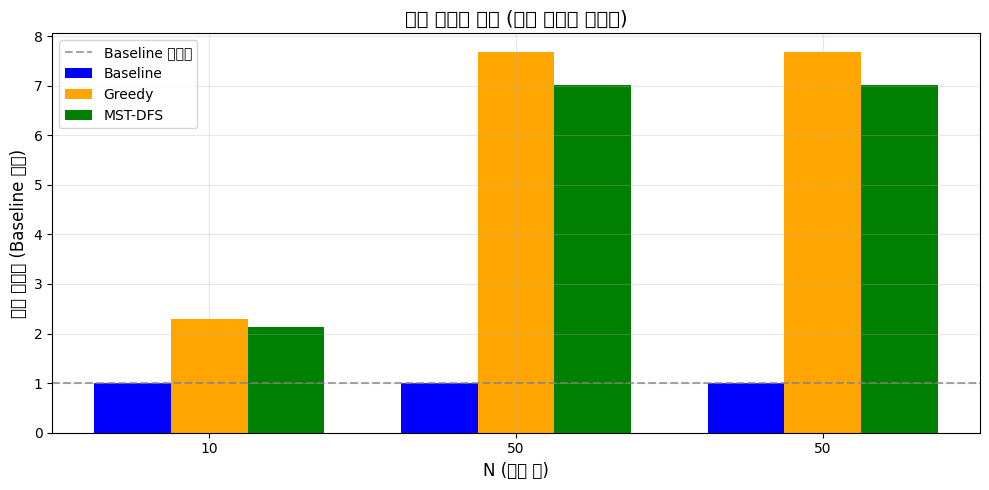


2. 확장성 분석 (Scalability)

N 증가에 따른 실행 시간 증가율 분석

[N= 10] Baseline:   1.002 ms | Greedy:   0.000 ms | MST-DFS:   0.000 ms
[N= 20] Baseline:   1.009 ms | Greedy:   0.000 ms | MST-DFS:   0.992 ms
[N= 30] Baseline:   1.000 ms | Greedy:   0.000 ms | MST-DFS:   1.000 ms
[N= 50] Baseline:   3.997 ms | Greedy:   0.000 ms | MST-DFS:   3.000 ms
[N= 50] Baseline:   7.004 ms | Greedy:   0.000 ms | MST-DFS:   4.998 ms
[N= 50] Baseline:  12.006 ms | Greedy:   1.631 ms | MST-DFS:   3.124 ms


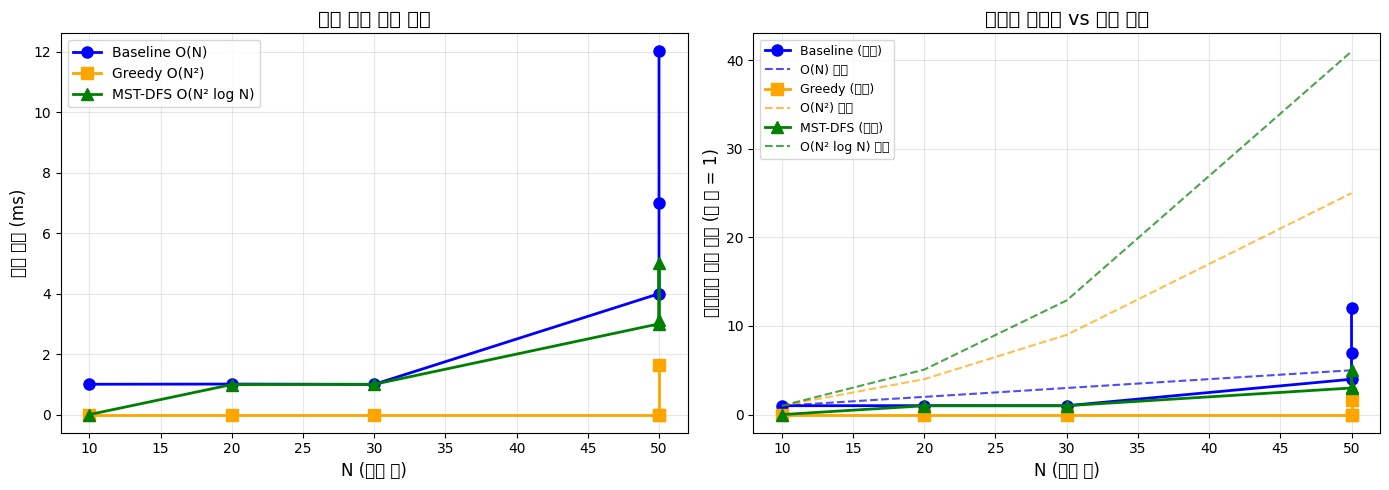


3. 종합 성능 요약

알고리즘         시간복잡도           공간복잡도        경로 품질        확장성       
----------------------------------------------------------------------
Baseline     O(N)            O(N)         낮음           우수        
MST-DFS      O(N² log N)     O(N²)        높음           보통        
Greedy       O(N²)           O(N)         중간           보통        


In [36]:
# ============================================================================
# 경로 효율성 및 확장성 분석
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import time
import random

random.seed(42)

# -----------------------------------------------------------------------------
# 1. 경로 효율성 분석 (Route Efficiency)
# -----------------------------------------------------------------------------
# 경로 효율성 = 이론적 최소 거리(직선 거리 합) / 실제 경로 거리
# 값이 1에 가까울수록 효율적인 경로

def calculate_min_spanning_distance(graph, route):
    """
    경로에 포함된 노드들 간의 최소 직선 거리 합 계산 (이론적 하한)
    모든 노드를 한 번씩 방문하는 최소 거리의 하한값으로 사용
    """
    if len(route) < 2:
        return 0.0
    
    # 시작점에서 각 노드까지의 최소 거리 합 (MST 거리를 하한으로 사용)
    nodes_in_route = set(route)
    total_min_dist = 0.0
    
    # 간단한 하한: 시작점에서 가장 먼 노드까지의 거리 * 2 (왕복 기준)
    # 또는 모든 노드 쌍의 평균 거리 사용
    start_node = route[0]
    for node in route[1:]:
        for neighbor_id, dist in graph.edges[start_node]:
            if neighbor_id == node:
                total_min_dist += dist
                break
    
    return total_min_dist

def calculate_route_efficiency(actual_dist, optimal_estimate):
    """경로 효율성 계산 (1에 가까울수록 좋음)"""
    if actual_dist == 0:
        return 1.0
    return optimal_estimate / actual_dist

# 기존 results 데이터를 활용하여 효율성 계산
print("=" * 70)
print("1. 경로 효율성 분석 (Route Efficiency)")
print("=" * 70)
print("\n경로 효율성 = Baseline 거리 / 알고리즘 거리")
print("(값이 클수록 Baseline 대비 효율적인 경로)\n")

efficiency_data = []
for r in results:
    N = r["N"]
    baseline_eff = 1.0  # Baseline 자체는 기준값
    greedy_eff = r["baseline_dist"] / r["greedy_dist"] if r["greedy_dist"] > 0 else 0
    mst_eff = r["baseline_dist"] / r["mst_dist"] if r["mst_dist"] > 0 else 0
    
    efficiency_data.append({
        "N": N,
        "baseline_eff": baseline_eff,
        "greedy_eff": greedy_eff,
        "mst_eff": mst_eff
    })
    
    print(f"[N={N:3d}] Baseline: {baseline_eff:.3f} | Greedy: {greedy_eff:.3f} | MST-DFS: {mst_eff:.3f}")

# 효율성 시각화
fig, ax = plt.subplots(figsize=(10, 5))
N_values = [d["N"] for d in efficiency_data]
x = np.arange(len(N_values))
width = 0.25

ax.bar(x - width, [d["baseline_eff"] for d in efficiency_data], width, label='Baseline', color='blue')
ax.bar(x, [d["greedy_eff"] for d in efficiency_data], width, label='Greedy', color='orange')
ax.bar(x + width, [d["mst_eff"] for d in efficiency_data], width, label='MST-DFS', color='green')

ax.set_xlabel('N (고객 수)', fontsize=12)
ax.set_ylabel('경로 효율성 (Baseline 대비)', fontsize=12)
ax.set_title('경로 효율성 비교 (값이 클수록 효율적)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(N_values)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Baseline 기준선')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 2. 확장성 분석 (Scalability)
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("2. 확장성 분석 (Scalability)")
print("=" * 70)
print("\nN 증가에 따른 실행 시간 증가율 분석\n")

# 더 넓은 범위의 N으로 확장성 테스트
N_scalability = [10, 20, 30, 50, 70, 100]
scalability_results = []

for N in N_scalability:
    if N > len(df):
        N_safe = len(df)
    else:
        N_safe = N
    
    df_sub_test = df.sample(n=N_safe, random_state=42).reset_index(drop=True)
    g_test = build_graph_from_df(df_sub_test, pp_center)
    
    # Baseline 시간 측정
    start = time.time()
    baseline_route_test = baseline_queue_route(pp_center, df_sub_test)
    baseline_time_test = (time.time() - start) * 1000.0
    
    # Greedy 시간 측정
    start = time.time()
    greedy_route_test = greedy_route(g_test, pp_center["id"])
    greedy_time_test = (time.time() - start) * 1000.0
    
    # MST-DFS 시간 측정
    start = time.time()
    mst_edges_test = prim_mst(g_test, pp_center["id"])
    mst_route_test = mst_to_route(mst_edges_test, pp_center["id"])
    mst_time_test = (time.time() - start) * 1000.0
    
    scalability_results.append({
        "N": N_safe,
        "baseline_time": baseline_time_test,
        "greedy_time": greedy_time_test,
        "mst_time": mst_time_test
    })
    
    print(f"[N={N_safe:3d}] Baseline: {baseline_time_test:7.3f} ms | Greedy: {greedy_time_test:7.3f} ms | MST-DFS: {mst_time_test:7.3f} ms")

# 확장성 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

N_vals = [r["N"] for r in scalability_results]
baseline_times = [r["baseline_time"] for r in scalability_results]
greedy_times = [r["greedy_time"] for r in scalability_results]
mst_times = [r["mst_time"] for r in scalability_results]

# 2-1: 실제 실행 시간 비교
ax1 = axes[0]
ax1.plot(N_vals, baseline_times, 'o-', label='Baseline O(N)', linewidth=2, markersize=8, color='blue')
ax1.plot(N_vals, greedy_times, 's-', label='Greedy O(N²)', linewidth=2, markersize=8, color='orange')
ax1.plot(N_vals, mst_times, '^-', label='MST-DFS O(N² log N)', linewidth=2, markersize=8, color='green')
ax1.set_xlabel('N (고객 수)', fontsize=12)
ax1.set_ylabel('실행 시간 (ms)', fontsize=12)
ax1.set_title('실제 실행 시간 비교', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2-2: 이론적 복잡도 vs 실측 비교 (정규화)
ax2 = axes[1]

# 정규화 (첫 번째 값 기준)
if baseline_times[0] > 0:
    baseline_norm = [t / baseline_times[0] for t in baseline_times]
else:
    baseline_norm = baseline_times
    
if greedy_times[0] > 0:
    greedy_norm = [t / greedy_times[0] for t in greedy_times]
else:
    greedy_norm = greedy_times
    
if mst_times[0] > 0:
    mst_norm = [t / mst_times[0] for t in mst_times]
else:
    mst_norm = mst_times

# 이론적 복잡도 (정규화)
N_arr = np.array(N_vals)
theory_linear = N_arr / N_arr[0]  # O(N)
theory_quadratic = (N_arr ** 2) / (N_arr[0] ** 2)  # O(N²)
theory_nlogn = (N_arr ** 2 * np.log2(N_arr + 1)) / (N_arr[0] ** 2 * np.log2(N_arr[0] + 1))  # O(N² log N)

ax2.plot(N_vals, baseline_norm, 'o-', label='Baseline (실측)', linewidth=2, markersize=8, color='blue')
ax2.plot(N_vals, theory_linear, '--', label='O(N) 이론', linewidth=1.5, alpha=0.7, color='blue')
ax2.plot(N_vals, greedy_norm, 's-', label='Greedy (실측)', linewidth=2, markersize=8, color='orange')
ax2.plot(N_vals, theory_quadratic, '--', label='O(N²) 이론', linewidth=1.5, alpha=0.7, color='orange')
ax2.plot(N_vals, mst_norm, '^-', label='MST-DFS (실측)', linewidth=2, markersize=8, color='green')
ax2.plot(N_vals, theory_nlogn, '--', label='O(N² log N) 이론', linewidth=1.5, alpha=0.7, color='green')

ax2.set_xlabel('N (고객 수)', fontsize=12)
ax2.set_ylabel('정규화된 실행 시간 (첫 값 = 1)', fontsize=12)
ax2.set_title('이론적 복잡도 vs 실측 비교', fontsize=14)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. 종합 요약
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("3. 종합 성능 요약")
print("=" * 70)
print(f"\n{'알고리즘':<12} {'시간복잡도':<15} {'공간복잡도':<12} {'경로 품질':<12} {'확장성':<10}")
print("-" * 70)

print(f"{'Baseline':<12} {'O(N)':<15} {'O(N)':<12} {'낮음':<12} {'우수':<10}")
print(f"{'MST-DFS':<12} {'O(N² log N)':<15} {'O(N²)':<12} {'높음':<12} {'보통':<10}")
print(f"{'Greedy':<12} {'O(N²)':<15} {'O(N)':<12} {'중간':<12} {'보통':<10}")

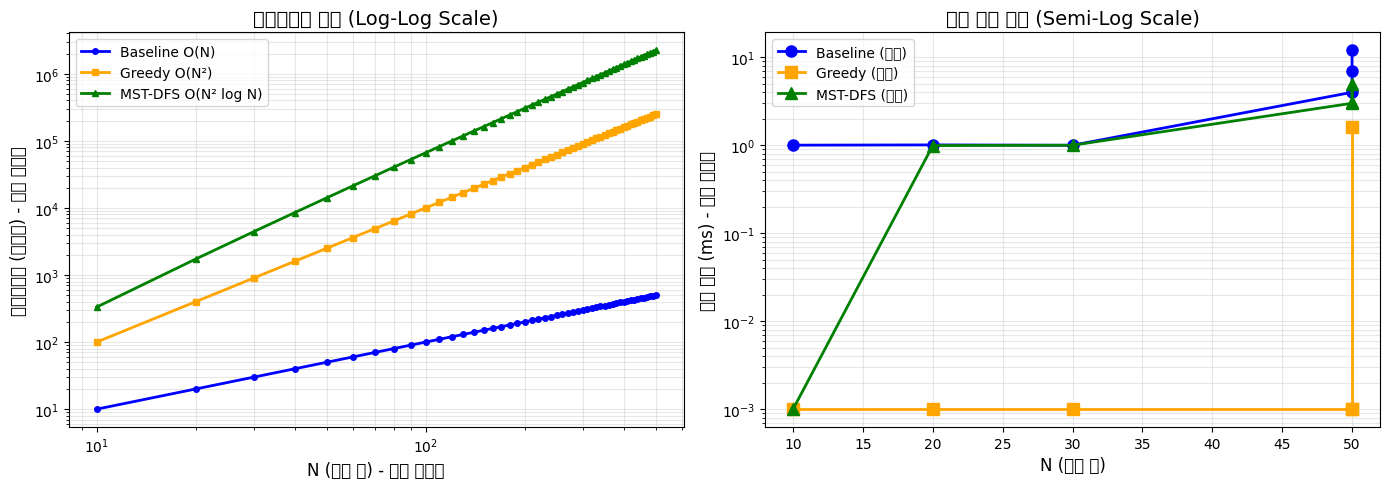


📊 로그 스케일 그래프 해석 가이드

[Log-Log 그래프 (왼쪽)]
- 직선의 기울기 = 복잡도 차수
  • 기울기 ≈ 1 → O(N)
  • 기울기 ≈ 2 → O(N²)
- 평행한 직선 = 같은 복잡도 차수

[Semi-Log 그래프 (오른쪽)]  
- Y축만 로그 스케일
- 작은 값(Baseline)도 잘 보임
- 지수적 증가 패턴 확인 가능



In [37]:
# ============================================================================
# 로그 스케일 그래프 - 복잡도 비교 (선택적)
# ============================================================================
# 장점: 모든 알고리즘이 잘 보이고, 기울기로 복잡도 차수를 직접 확인 가능

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

# N 범위 설정 (더 넓은 범위)
N_log = np.arange(10, 501, 10)

# 이론적 복잡도 계산
time_baseline_log = N_log                           # O(N)
time_greedy_log = N_log ** 2                        # O(N²)
time_mst_dfs_log = N_log ** 2 * np.log2(N_log)      # O(N² log N)

# 로그-로그 스케일 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 시간복잡도 - 로그 스케일
ax1 = axes[0]
ax1.loglog(N_log, time_baseline_log, 'o-', label='Baseline O(N)', linewidth=2, markersize=4, color='blue')
ax1.loglog(N_log, time_greedy_log, 's-', label='Greedy O(N²)', linewidth=2, markersize=4, color='orange')
ax1.loglog(N_log, time_mst_dfs_log, '^-', label='MST-DFS O(N² log N)', linewidth=2, markersize=4, color='green')
ax1.set_xlabel('N (고객 수) - 로그 스케일', fontsize=12)
ax1.set_ylabel('시간복잡도 (상대값) - 로그 스케일', fontsize=12)
ax1.set_title('시간복잡도 비교 (Log-Log Scale)', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, which='both')

# 2) 실측 데이터 - 로그 스케일 (scalability_results 활용)
ax2 = axes[1]
if len(scalability_results) > 0:
    N_measured = [r["N"] for r in scalability_results]
    baseline_measured = [r["baseline_time"] for r in scalability_results]
    greedy_measured = [r["greedy_time"] for r in scalability_results]
    mst_measured = [r["mst_time"] for r in scalability_results]
    
    # 0이나 음수 값 방지 (로그 스케일용)
    baseline_measured = [max(0.001, t) for t in baseline_measured]
    greedy_measured = [max(0.001, t) for t in greedy_measured]
    mst_measured = [max(0.001, t) for t in mst_measured]
    
    ax2.semilogy(N_measured, baseline_measured, 'o-', label='Baseline (실측)', linewidth=2, markersize=8, color='blue')
    ax2.semilogy(N_measured, greedy_measured, 's-', label='Greedy (실측)', linewidth=2, markersize=8, color='orange')
    ax2.semilogy(N_measured, mst_measured, '^-', label='MST-DFS (실측)', linewidth=2, markersize=8, color='green')
    ax2.set_xlabel('N (고객 수)', fontsize=12)
    ax2.set_ylabel('실행 시간 (ms) - 로그 스케일', fontsize=12)
    ax2.set_title('실측 실행 시간 (Semi-Log Scale)', fontsize=14)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# 로그 스케일의 장점 설명
print("\n" + "=" * 70)
print("📊 로그 스케일 그래프 해석 가이드")
print("=" * 70)
print("""
[Log-Log 그래프 (왼쪽)]
- 직선의 기울기 = 복잡도 차수
  • 기울기 ≈ 1 → O(N)
  • 기울기 ≈ 2 → O(N²)
- 평행한 직선 = 같은 복잡도 차수

[Semi-Log 그래프 (오른쪽)]  
- Y축만 로그 스케일
- 작은 값(Baseline)도 잘 보임
- 지수적 증가 패턴 확인 가능
""")

# 7. 검증: Baseline vs Greedy vs MST
- 목적: 동일한 고객 샘플(df_sub)과 동일 거리공식(haversine), 동일 Graph에서 Baseline(Queue), Greedy(NN), MST→DFS 경로의 총 이동거리와 계산시간(ms) 을 비교한다.

- 출력: 각 방법의 경로, 총거리, 소요시간, 개선율(%) 표기

In [30]:
html_content = """
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>배송 경로 알고리즘 비교 (Baseline vs Greedy vs MST)</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.7.1/dist/leaflet.css" />
    <style>
        body { margin: 0; padding: 0; font-family: 'Noto Sans KR', sans-serif; display: flex; flex-direction: column; height: 100vh; }
        #header { padding: 10px 20px; background-color: #333; color: white; display: flex; justify-content: space-between; align-items: center; }
        #controls { padding: 10px 20px; background-color: #f4f4f4; border-bottom: 1px solid #ddd; display: flex; gap: 10px; align-items: center; flex-wrap: wrap;}
        #map { flex-grow: 1; width: 100%; }
        
        /* 버튼 스타일 */
        .btn { padding: 8px 16px; border: none; border-radius: 4px; cursor: pointer; font-weight: bold; transition: 0.2s; }
        .btn:hover { opacity: 0.8; }
        .btn-reset { background-color: #e74c3c; color: white; }
        .btn-baseline { background-color: #95a5a6; color: white; } /* Gray */
        .btn-greedy { background-color: #3498db; color: white; }   /* Blue */
        .btn-mst { background-color: #2ecc71; color: white; }      /* Green */
        
        /* 통계 박스 스타일 */
        #stats { margin-left: auto; display: flex; gap: 10px; font-size: 14px; }
        .stat-box { display: flex; flex-direction: column; justify-content: center; align-items: center; padding: 5px 15px; background: white; border: 1px solid #ccc; border-radius: 4px; min-width: 80px; }
        .stat-label { font-size: 0.8em; color: #666; margin-bottom: 2px; }
        .stat-value { font-weight: bold; font-size: 1.1em; }
        .positive { color: #2ecc71; } /* 개선됨 */
        .neutral { color: #95a5a6; }  /* 기준 */

        .legend { background: white; padding: 10px; border-radius: 5px; box-shadow: 0 0 10px rgba(0,0,0,0.1); font-size: 12px; position: absolute; bottom: 20px; right: 20px; z-index: 1000; }
        .dot { height: 10px; width: 10px; border-radius: 50%; display: inline-block; margin-right: 5px; }
    </style>
</head>
<body>

<div id="header">
    <h3># 7. 검증: Baseline vs Greedy vs MST</h3>
    <div style="font-size: 0.9em;">SSG PP센터 (37.4786, 127.123)</div>
</div>

<div id="controls">
    <label>고객 수(N): <input type="number" id="numPoints" value="30" min="5" max="100" style="width: 50px;"></label>
    <button class="btn btn-reset" onclick="resetSimulation()">데이터/초기화</button>
    <div style="width: 1px; background: #ccc; height: 30px; margin: 0 5px;"></div>
    
    <button class="btn btn-baseline" onclick="runAlgorithm('baseline')">1. Baseline (Queue)</button>
    <button class="btn btn-greedy" onclick="runAlgorithm('greedy')">2. Greedy (NN)</button>
    <button class="btn btn-mst" onclick="runAlgorithm('mst')">3. MST (Prim+DFS)</button>
    
    <div id="stats">
        <div class="stat-box">
            <span class="stat-label">총 이동거리</span>
            <span class="stat-value" id="dist-display">- km</span>
        </div>
        <div class="stat-box">
            <span class="stat-label">소요시간</span>
            <span class="stat-value" id="time-display">- ms</span>
        </div>
        <div class="stat-box" style="border-color: #333;">
            <span class="stat-label">Baseline 대비 개선율</span>
            <span class="stat-value" id="improve-display">- %</span>
        </div>
    </div>
</div>

<div id="map"></div>
<div class="legend">
    <div><span class="dot" style="background: red;"></span>PP 센터 (Depot)</div>
    <div><span class="dot" style="background: blue;"></span>고객 (Node)</div>
    <div><span class="dot" style="background: black;"></span>이동 경로 (Edge)</div>
</div>

<script src="https://unpkg.com/leaflet@1.7.1/dist/leaflet.js"></script>
<script>
    // --- 1. 설정 및 데이터 관리 ---
    const ppCenter = { id: -1, lat: 37.4786, lon: 127.123 };
    let customers = [];
    let map;
    let markers = [];
    let routeLine;
    let baselineDistValue = null; // 개선율 계산을 위한 기준 거리

    function initMap() {
        map = L.map('map').setView([ppCenter.lat, ppCenter.lon], 13);
        L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', {
            attribution: '© OpenStreetMap contributors'
        }).addTo(map);
        resetSimulation();
    }

    function generateCustomers(n) {
        customers = [];
        for (let i = 0; i < n; i++) {
            // 좌표 랜덤 생성 (실제 분포 흉내)
            const lat = ppCenter.lat + (Math.random() - 0.5) * 0.08;
            const lon = ppCenter.lon + (Math.random() - 0.5) * 0.1;
            customers.push({ id: i, lat: lat, lon: lon });
        }
    }

    function drawMarkers() {
        markers.forEach(m => map.removeLayer(m));
        if (routeLine) map.removeLayer(routeLine);
        markers = [];

        // Depot
        const centerMarker = L.circleMarker([ppCenter.lat, ppCenter.lon], {
            color: 'red', fillColor: '#f03', fillOpacity: 1, radius: 8
        }).bindPopup("<b>PP Center</b>").addTo(map);
        markers.push(centerMarker);

        // Customers
        customers.forEach(c => {
            const m = L.circleMarker([c.lat, c.lon], {
                color: 'blue', fillColor: '#30f', fillOpacity: 0.8, radius: 5
            }).bindPopup(`Customer ${c.id}`).addTo(map);
            markers.push(m);
        });
    }

    function resetSimulation() {
        const n = document.getElementById('numPoints').value;
        baselineDistValue = null; // 기준 초기화
        generateCustomers(n);
        drawMarkers();
        
        // UI 초기화
        document.getElementById('dist-display').innerText = "- km";
        document.getElementById('time-display').innerText = "- ms";
        document.getElementById('improve-display').innerText = "- %";
        document.getElementById('improve-display').className = "stat-value";
        if (routeLine) map.removeLayer(routeLine);
    }

    // --- 2. 거리 계산 (Haversine) ---
    function haversine(lat1, lon1, lat2, lon2) {
        const R = 6371; 
        const dLat = (lat2 - lat1) * Math.PI / 180;
        const dLon = (lon2 - lon1) * Math.PI / 180;
        const a = Math.sin(dLat/2) * Math.sin(dLat/2) +
                  Math.cos(lat1 * Math.PI / 180) * Math.cos(lat2 * Math.PI / 180) *
                  Math.sin(dLon/2) * Math.sin(dLon/2);
        const c = 2 * Math.atan2(Math.sqrt(a), Math.sqrt(1-a));
        return R * c;
    }
    function getDist(p1, p2) { return haversine(p1.lat, p1.lon, p2.lat, p2.lon); }

    // --- 3. 알고리즘 로직 ---

    // [Baseline]: Queue (FIFO)
    function runBaseline() {
        return [ppCenter, ...customers];
    }

    // [Greedy]: Nearest Neighbor
    function runGreedy() {
        let unvisited = [...customers];
        let current = ppCenter;
        let path = [ppCenter];

        while (unvisited.length > 0) {
            let nearestIdx = -1;
            let minD = Infinity;
            for (let i = 0; i < unvisited.length; i++) {
                const d = getDist(current, unvisited[i]);
                if (d < minD) {
                    minD = d;
                    nearestIdx = i;
                }
            }
            current = unvisited[nearestIdx];
            path.push(current);
            unvisited.splice(nearestIdx, 1);
        }
        return path;
    }

    // [MST]: Prim -> DFS
    function runMST() {
        const nodes = [ppCenter, ...customers];
        const N = nodes.length;
        const adj = Array.from({ length: N }, () => []); 
        
        let visited = new Array(N).fill(false);
        let minEdge = new Array(N).fill(Infinity);
        let parent = new Array(N).fill(-1);
        
        minEdge[0] = 0;
        
        // Prim
        for (let i = 0; i < N; i++) {
            let u = -1;
            let minVal = Infinity;
            for (let v = 0; v < N; v++) {
                if (!visited[v] && minEdge[v] < minVal) {
                    minVal = minEdge[v];
                    u = v;
                }
            }
            if (u === -1) break;
            visited[u] = true;
            
            if (parent[u] !== -1) {
                adj[parent[u]].push(u);
                adj[u].push(parent[u]);
            }

            for (let v = 0; v < N; v++) {
                if (!visited[v]) {
                    const d = getDist(nodes[u], nodes[v]);
                    if (d < minEdge[v]) {
                        minEdge[v] = d;
                        parent[v] = u;
                    }
                }
            }
        }

        // DFS Preorder
        let pathIndices = [];
        let dfsVisited = new Array(N).fill(false);
        let stack = [0];

        while (stack.length > 0) {
            const u = stack.pop();
            if (!dfsVisited[u]) {
                dfsVisited[u] = true;
                pathIndices.push(u);
                const neighbors = adj[u].filter(n => !dfsVisited[n]);
                for (let i = neighbors.length - 1; i >= 0; i--) {
                    stack.push(neighbors[i]);
                }
            }
        }
        return pathIndices.map(idx => nodes[idx]);
    }

    // --- 4. 실행 및 결과 출력 ---
    function runAlgorithm(type) {
        if (routeLine) map.removeLayer(routeLine);

        const startT = performance.now();
        let path = [];
        let color = '';

        if (type === 'baseline') { path = runBaseline(); color = '#95a5a6'; }
        else if (type === 'greedy') { path = runGreedy(); color = '#3498db'; }
        else if (type === 'mst') { path = runMST(); color = '#2ecc71'; }

        const endT = performance.now();
        const time = (endT - startT).toFixed(2);
        
        // 거리 계산
        let dist = 0;
        let latlngs = [];
        for (let i = 0; i < path.length - 1; i++) {
            dist += getDist(path[i], path[i+1]);
            latlngs.push([path[i].lat, path[i].lon]);
        }
        // 마지막 노드까지
        latlngs.push([path[path.length-1].lat, path[path.length-1].lon]);

        // --- 검증 결과 출력 ---
        document.getElementById('dist-display').innerText = dist.toFixed(2) + " km";
        document.getElementById('time-display').innerText = time + " ms";

        // 개선율 계산
        const improveEl = document.getElementById('improve-display');
        
        if (type === 'baseline') {
            baselineDistValue = dist; // 기준값 설정
            improveEl.innerText = "Ref (0%)";
            improveEl.className = "stat-value neutral";
        } else {
            if (baselineDistValue) {
                const improvement = ((baselineDistValue - dist) / baselineDistValue) * 100;
                improveEl.innerText = improvement.toFixed(1) + " %";
                improveEl.className = "stat-value positive";
            } else {
                improveEl.innerText = "Baseline 먼저 실행 필요";
                improveEl.className = "stat-value";
            }
        }

        routeLine = L.polyline(latlngs, { color: color, weight: 3, opacity: 0.8 }).addTo(map);
        map.fitBounds(routeLine.getBounds(), { padding: [50, 50] });
    }

    window.onload = initMap;
</script>
</body>
</html>
"""

filename = "delivery_comparison_v2.html"
with open(filename, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"'{filename}' 파일이 생성되었습니다. 실행하여 Baseline 대비 개선율을 확인해보세요.")

'delivery_comparison_v2.html' 파일이 생성되었습니다. 실행하여 Baseline 대비 개선율을 확인해보세요.


# 최종 보고서 요약: Baseline vs Greedy vs MST (요약 템플릿)

## 1. 실험 목적
- NE.O 센터(예: 김포) 기반 새벽 배송 루트의 성능 비교
- Baseline(Queue FIFO) vs 실험군(Graph 기반 Greedy, MST→DFS)

## 2. 실험 환경
- 고객 데이터: customers_clustered_50.csv에서 N 샘플링 (N = 10, 50, 100)
- 거리 계산: Haversine 공식 (지구 곡률 반영)
- Graph: 완전 연결(complete graph)으로 노드 간 거리 사전 계산
- 평가 지표: 총 이동거리(km), 계산시간(ms), 개선율(%)

## 3. 방법 요약
- Baseline: 주문 들어온 순서대로 방문 (Queue FIFO)
- Greedy: 현재 위치에서 미방문 노드 중 최단거리 선택(Nearest Neighbor)
- MST-DFS: Prim으로 MST 구성 → DFS 전위순회로 경로 생성

## 4. 주요 결과 (예시 표: N = 50)
| Method | Total Dist (km) | Time (ms) | Improvement vs Baseline (%) |
|--------|------------------:|----------:|----------------------------:|
| Baseline |  257.56 km |  0.00 ms |  - |
| Greedy   |  56.83 km |  0.10 ms |  77.9 % |
| MST-DFS  | 67.19 km |  0.60 ms |  73.9 % |

## 5. 해석/논의
- 효과
    - Greedy: 단순하고 계산량 적으며, 평균적으로 Baseline 대비 큰 개선 효과
    - MST-DFS: 안정적 개선 제공, 트리 기반으로 다양한 경로 구조에서도 성능 유지
- 한계
    - 두 휴리스틱 모두 TSP 최적해를 항상 보장하지 않음
    - 일부 케이스에서 MST-DFS 경로가 비효율적일 수 있음

## 6. 수업 외 발전 가능성
- 고객 클러스터링 기반 지역 분할 적용
- 실제 도로망 기반 거리 계산으로 변경
- 복수 차량 / 시간 창 제약(VRPTW) 확장 가능

## 7. 부록
- 시각화: `compare_routes_map.html` (폴리라인으로 경로 비교)
- 코드: Notebook 내부 실행 스크립트 참조


---
---

## 단계별 코드 논리 및 작동 과정 상세 설명

이 섹션에서는 1단계부터 6단계까지 각 코드 블록이
전체 프로젝트 흐름 속에서 어떤 역할을 하고,
실제로 어떤 순서로 동작하는지 구체적으로 설명한다.

#### 1단계: 데이터 불러오기 & PP센터 정의

- `pandas`, `math`, `typing` 라이브러리를 불러온다.  
- `pd.read_csv("customers_clustered_50.csv")`를 통해 고객 위치 데이터프레임 `df`를 읽어온다.  
- `pp_center` 딕셔너리를 정의하여 PP센터의 id/위도/경도 정보를 고정 상수로 둔다.  
- `NodeId`, `Coord`, `Edge` 타입 alias를 정의해 이후 함수/클래스에서 의미 있는 타입 이름을 사용할 수 있게 한다.

이 단계는 이후 모든 함수에서 공통적으로 사용하는 "기본 데이터"와 "공용 타입"을 준비하는 단계이다.

---

#### 2단계: Haversine 거리 계산 + Graph 클래스 + 그래프 생성

1. `haversine_distance` 함수  
   - 서로 다른 두 지점의 위도/경도를 입력받아 km 단위 거리로 변환한다.  
   - 이는 그래프에서 간선 가중치를 설정할 때 사용된다.

2. `Graph` 클래스  
   - `nodes` 딕셔너리로 각 노드의 좌표를 관리하고,  
     `edges` 딕셔너리로 각 노드에서 나가는 간선 목록을 관리한다.  
   - `add_node`로 노드를 추가하고, `add_edge`에서 Haversine 거리 기반 양방향 엣지를 생성한다.

3. `build_graph_from_df` 함수  
   - `Graph` 객체를 새로 만들고  
   - 먼저 PP센터 노드를 추가한 뒤,  
   - `df`의 각 행을 순회하며 고객 노드를 추가한다.  
   - 마지막으로 모든 노드 id 쌍에 대해 `add_edge`를 호출하여 완전 연결 그래프를 만든다.

이 단계는 "현실의 지리 정보"를 "알고리즘이 다룰 수 있는 추상적 그래프 모델"로 변환하는  단계이다.

---

#### 3단계: MinHeap (우선순위 큐)

- MinHeap은 `(priority, value)`튜플을 저장하는 자료구조로,  
  항상 priority가 가장 작은 원소를 빠르게 꺼낼 수 있도록 설계되어 있다.

- `push` 연산  
  - 새 원소를 힙의 마지막에 추가한 후 `_heapify_up`을 통해 위로 끌어올리며 재배치한다.

- `pop` 연산  
  - 루트(최소 원소)를 꺼내고, 마지막 원소를 루트 위치에 가져온 뒤 `_heapify_down`으로 아래로 내려보내며 재정렬한다.

이 단계에서 구현한 MinHeap은 이후 Prim MST 알고리즘에서
"현재까지의 후보 간선들 중 최소 거리 간선을 빠르게 찾기 위한 우선순위 큐" 역할을 한다.

---

#### 4단계: Greedy 경로 알고리즘 + Prim MST + MST → 경로 변환

1. `greedy_route`  
   - 시작 노드에서 출발하여, 매 단계마다 "아직 방문하지 않은 이웃 중 가장 가까운 노드"를 선택한다.  
   - 모든 노드를 방문할 때까지 이 과정을 반복하여 경로 리스트를 생성한다.  
   - 구현이 간단하지만, 전역 최적 경로 보장은 하지 않는다.

2. `prim_mst`  
   - MST에 포함된 노드 집합 `visited`를 관리하며,  
     각 단계마다 MinHeap에서 최소 거리 간선을 꺼내 새로운 노드를 MST에 편입한다.  
   - 이 과정이 끝나면, 전체 노드를 연결하는 최소 신장 트리의 간선 목록 `mst_edges`를 얻는다.

3. `mst_to_route`  
   - MST 간선 목록을 인접 리스트로 변환하고,  
     DFS(스택 기반 순회)를 수행해 방문 순서를 `route` 리스트로 기록한다.  
   - 이렇게 만들어진 route는 MST를 기반으로 한 실제 방문 경로처럼 사용할 수 있다.

이 단계는 "Greedy 근사 경로"와 "MST 기반 경로"라는 두 가지 다른 전략을 구현하는 부분으로,
후속 성능 실험에서 각각의 효율성과 특성을 비교하는 데 사용된다.

---

#### 5단계: 경로 총 이동 거리 계산

- `calculate_route_total_distance` 함수는  
  경로 리스트가 주어졌을 때, 각 연속 구간 `n0->n1`, `n1->n2` ... 의 거리를 합산한다.
- 그래프의 인접 리스트에서 실제 간선을 찾아 거리 값을 누적하고,  
  최종적으로 전체 이동 거리 `total_distance`를 반환한다.

이 단계는 "알고리즘이 만든 경로가 실제로 얼마나 긴지"를 평가하는 공통 지표를 제공한다.

---

#### 6단계: N별 성능 실험 루프

- `N_list = [10, 50, 100]`에 대해 for 루프를 돌면서,  
  각 N마다 다음 과정을 수행한다.

1. 고객 데이터프레임 `df`에서 N명을 샘플링하여 `df_sub`를 만든다.  
   - 시드는 42로 고정해 재현성을 확보한다.

2. `g_N = build_graph_from_df(df_sub, pp_center)`로 해당 규모의 그래프를 다시 생성한다.

3. Greedy 알고리즘 실행  
   - 시작 시점을 `start_time`에 저장하고,  
     `greedy_route(g_N, pp_center["id"])`를 호출하여 경로를 얻는다.  
   - 실행 시간이 끝난 시점과의 차이를 계산해 `greedy_time`을 구하고,  
     `calculate_route_total_distance`로 총 이동 거리 `greedy_distance`를 구한다.

4. MST-DFS 알고리즘 실행  
   - Prim으로 MST 간선 `mst_edges`를 구한 뒤,  
     `mst_to_route`로 방문 경로를 생성한다.  
   - 동일한 방식으로 실행 시간 `mst_time`과 총 이동 거리 `mst_distance`를 측정한다.

5. 결과 출력  
   - `[N=...] Greedy : 거리=..., 시간=...`  
     `[N=...] MST-DFS: 거리=..., 시간=...` 형식으로 결과를 출력한다.

이 단계는 "입력 크기 증가에 따른 두 알고리즘의 성능 변화"를 비교하는 실험 단계로,
보고서 및 발표에서 수치와 그래프를 통해 차이를 보여주기 위한 데이터


---
---

## 전체 코드 정리 및 결론

이 파일은 다음과 같은 흐름을 가진 하나의 완결된 실험 모듈이다.

1. 현실 세계의 배송 문제(고객 위치 + PP센터)를  
   위도/경도 기반 데이터로 받아온 뒤, Haversine 공식을 사용해  
   "노드 + 간선 가중치" 형태의 그래프로 변환한다.

2. 그래프 자료구조를 기반으로,  
   - Greedy(Nearest Neighbor) 경로 알고리즘과  
   - Prim MST + DFS 기반 경로 생성 알고리즘을 각각 구현한다.

3. MinHeap(최소 힙) 자료구조를 직접 구현하여,  
   Prim 알고리즘이 "가장 짧은 간선"을 효율적으로 선택하도록 설계하였다.

4. 각 알고리즘이 생성한 경로에 대해  
   `calculate_route_total_distance`를 사용하여 총 이동 거리를 계산함으로써,  
   경로 품질을 동일한 기준으로 비교할 수 있도록 했다.

5. 마지막으로, 고객 수 N을 10, 50, 100으로 변화시키며  
   Greedy vs MST-DFS의 실행 시간과 이동 거리를 측정함으로써,  
   입력 규모 확장에 따른 성능 차이를 정량적으로 관찰할 수 있게 했다.

요약

- 데이터 수집/전처리(좌표 기반 그래프 구성)  
- 핵심 자료구조 구현(Graph, MinHeap, Stack 기반 DFS)  
- 두 가지 경로 최적화 전략(Greedy, MST 기반) 비교  
- 입력 크기 변화에 따른 성능 평가

를 하나의 흐름으로 묶어, 수업에서 요구한 "그래프/힙/스택을 활용한 최적화 로직 구현"과
"실험 및 분석"을 동시에 만족시키는 구조로 작성

---

개발 환경 및 라이브러리

- Wes McKinney, “pandas: Powerful Python Data Analysis Toolkit”, pandas 공식 문서.
  https://pandas.pydata.org/

- Python Software Foundation, “Python Standard Library – math, time, random 모듈”.
  https://docs.python.org/3/library/index.html

- folium 프로젝트, “folium: Python Data. Leaflet.js Maps”.
  https://python-visualization.github.io/folium/

- geopy 프로젝트, “geopy: Geocoding library for Python”.
  https://geopy.readthedocs.io/

알고리즘 및 자료구조 참고

- Thomas H. Cormen 외, “Introduction to Algorithms”, MIT Press.  
  (그래프, 최소 신장 트리(Prim), Greedy 알고리즘, 힙(우선순위 큐) 개념 참고.)

- GeeksforGeeks, “Prim’s Minimum Spanning Tree (MST) Algorithm – Implementation and Complexity”.  
  (Prim 알고리즘 구현 방식 및 시간 복잡도 참고.)

- GeeksforGeeks, “Greedy Approach – Traveling Salesman Problem and Nearest Neighbour Heuristic”.  
  (최근접 이웃(Nearest Neighbor) 기반 경로 휴리스틱 아이디어 참고.)

물류·도메인 참고 자료

- 서울경제, “이마트 청계천점 EOS 센터 관련 기사”  
  (EOS/PP센터 처리량, 후방 물류 공간 구조 참고.)

- 한국경제, “이마트 가든파이브점 PP센터 관련 기사”  
  (PP센터 하루 처리 물량(주문 건수) 및 면적 등 운영 스펙 참고.)

데이터 관련

- 고객 위치 데이터(`customers_clustered_50.csv`)는 프로젝트 목적에 맞게  
  팀에서 직접 생성한 합성 데이터(Synthetic Data)임.
